# MultivariableFeatureSelection_RecurrenceStatus.ipynb

STABL-Cox cross-validation pipeline

**Prerequisites:** Run cells 1–19 first to produce
`dfPatientAnnData_LUAD` and the survival outcome `Y`.

Thereafter, the feature selection pipeline follows

`conda create -n analysis scikit-survival scikit-learn matplotlib pandas anndata`


`pip install git+https://github.com/gregbellan/Stabl.git@v1.0.1-lw`


`git clone https://github.com/clinicalomx/spatial_analysis.git`

`cd spatial_analysis`

`pip install .`


In [ ]:
import sksurv
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import RepeatedStratifiedKFold

from thresholded_cox import ThresholdedCoxPH, PerFeatureThresholder, NaNAwareStandardScaler
from scipy import stats
from sksurv.linear_model import CoxPHSurvivalAnalysis

from sklearn.model_selection import ParameterGrid
from sksurv.metrics import concordance_index_censored
from sksurv.ensemble import RandomSurvivalForest

from sklearn.model_selection import ParameterGrid
from sksurv.metrics import concordance_index_censored

from sksurv.ensemble import GradientBoostingSurvivalAnalysis

random_state = 42

from stabl.stabl import Stabl
from stabl.adaptive import ALasso
from stabl.preprocessing import LowInfoFilter

from cox_fits import CoxnetFitter
from cox_cv_pipeline import survival_stabl_cv

# Existing splitter building-blocks (no modifications to the original file)
from survival_splitters import SurvivalStratifyMixin, StrictGroupMixin

import JSD
import gcross

import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

## Create the Spatial Features

In [ ]:
adata = ad.read_h5ad(r'../adjTMA_xbounds_withCNs.h5ad')

gcross.calculate_gcrossauc(adata, mark_key='CT_final', library_key='unique_core', calculation_radii=np.arange(0, 500, 5), edge_correction='hanisch')
gcross.calculate_gcrossauc(adata, mark_key='Metabolic_baseCT', library_key='unique_core', calculation_radii=np.arange(0, 500, 5), edge_correction='hanisch')
gcross.calculate_gcrossauc(adata, mark_key='base_celltypes', library_key='unique_core', calculation_radii=np.arange(0, 500, 5), edge_correction='hanisch')
adata

AnnData object with n_obs × n_vars = 1187511 × 48
    obs: 'Image', 'Object ID', 'Name', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'CD4_type', 'CD8_type', 'mac_type', 'Tumour_type', 'Tumour_type_tidy', 'unique_core', 'patientID', 'adjtma_PCF_repA', 'adjtma_PCF_repB', 'dict', 'DSP_WTA_ROI', 'TNM', 'stage', 'PathwayCode', 'Histology', 'Sex', 'Smoking', 'EndCycle', 'DOB', 'Date of surgery', 'StartDate', 'Deceased', 'DateDeceased', 'Relapse', 'Date of relapse', 'Molecular profile', 'Mutation', 'Last known contact', 'Surv_status', 'Surv_Followup', 'Relapse_status', 'Relapse_followup', 'tregion', 'tumourdist', 'Tumour_area', 'Tumour_pc', 'Stroma_area', 'Stroma_pc', 'CT_final', 'CT_basetumour', 'base_celltypes', 'batch', 'PD-L1_pos', 'PD-1_pos', 'HLA-DR_pos', 'HLA-A_pos', 'ICOS(CD278)_pos', 'PAX5_pos', 'FOXP3_pos', 'Ki67_pos', 'Granzyme_B_pos', 'G6PD_pos', 'pNRF2_pos', 

In [3]:
adata.obs.keys()

Index(['Image', 'Object ID', 'Name', 'TMA core', 'Parent', 'ROI', 'x', 'y',
       'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity',
       'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'CD4_type',
       'CD8_type', 'mac_type', 'Tumour_type', 'Tumour_type_tidy',
       'unique_core', 'patientID', 'adjtma_PCF_repA', 'adjtma_PCF_repB',
       'dict', 'DSP_WTA_ROI', 'TNM', 'stage', 'PathwayCode', 'Histology',
       'Sex', 'Smoking', 'EndCycle', 'DOB', 'Date of surgery', 'StartDate',
       'Deceased', 'DateDeceased', 'Relapse', 'Date of relapse',
       'Molecular profile', 'Mutation', 'Last known contact', 'Surv_status',
       'Surv_Followup', 'Relapse_status', 'Relapse_followup', 'tregion',
       'tumourdist', 'Tumour_area', 'Tumour_pc', 'Stroma_area', 'Stroma_pc',
       'CT_final', 'CT_basetumour', 'base_celltypes', 'batch', 'PD-L1_pos',
       'PD-1_pos', 'HLA-DR_pos', 'HLA-A_pos', 'ICOS(CD278)_pos', 'PAX5_pos',
       'FOXP3_pos', 'Ki67_pos', 'Gra

In [4]:
adata.obs[['stage_grouped', ]].value_counts()

stage_grouped
stage2           682888
stage3           333018
stage1           171605
Name: count, dtype: int64

In [ ]:
jsd = JSD.Spatial2DDensityCorrelation(adata, 'CT_final', 'unique_core')
jsd.computeJSDAllCellTypes()

Computing for TMA_A_A1
Computing for TMA_A_A2
Computing for TMA_A_A3
Computing for TMA_A_A4
Computing for TMA_A_A5
Computing for TMA_A_A6
Computing for TMA_A_A7
Computing for TMA_A_B2
Computing for TMA_A_B3
Computing for TMA_A_B4
Computing for TMA_A_B5
Computing for TMA_A_B6
Computing for TMA_A_B7
Computing for TMA_A_C1
Computing for TMA_A_C2
Computing for TMA_A_C3
Computing for TMA_A_C4
Computing for TMA_A_C5
Computing for TMA_A_C6
Computing for TMA_A_C7
Computing for TMA_A_D1
Computing for TMA_A_D5
Computing for TMA_A_D6
Computing for TMA_A_D7
Computing for TMA_A_E1
Computing for TMA_A_E3
Computing for TMA_A_E4
Computing for TMA_A_E5
Computing for TMA_A_E6
Computing for TMA_A_E7
Computing for TMA_A_F1
Computing for TMA_A_F3
Computing for TMA_A_F4
Computing for TMA_A_F5
Computing for TMA_A_F6
Computing for TMA_A_F7
Computing for TMA_A_G1
Computing for TMA_A_G2
Computing for TMA_A_G3
Computing for TMA_A_G4
Computing for TMA_A_G5
Computing for TMA_A_G6
Computing for TMA_A_G7
Computing f

In [9]:
jsd.results

{('TMA_A_A1', 'Macrophages_PDL1+', 'Tumour'): nan,
 ('TMA_A_A1', 'Tumour', 'Macrophages_PDL1+'): nan,
 ('TMA_A_A1', 'Macrophages_PDL1+', 'CD4_cells'): nan,
 ('TMA_A_A1', 'CD4_cells', 'Macrophages_PDL1+'): nan,
 ('TMA_A_A1', 'Macrophages_PDL1+', 'Fibroblast'): nan,
 ('TMA_A_A1', 'Fibroblast', 'Macrophages_PDL1+'): nan,
 ('TMA_A_A1', 'Macrophages_PDL1+', 'Vessels'): nan,
 ('TMA_A_A1', 'Vessels', 'Macrophages_PDL1+'): nan,
 ('TMA_A_A1', 'Macrophages_PDL1+', 'Other_Stromal_cells'): nan,
 ('TMA_A_A1', 'Other_Stromal_cells', 'Macrophages_PDL1+'): nan,
 ('TMA_A_A1', 'Macrophages_PDL1+', 'Macrophages'): nan,
 ('TMA_A_A1', 'Macrophages', 'Macrophages_PDL1+'): nan,
 ('TMA_A_A1', 'Macrophages_PDL1+', 'MHC_II'): nan,
 ('TMA_A_A1', 'MHC_II', 'Macrophages_PDL1+'): nan,
 ('TMA_A_A1', 'Macrophages_PDL1+', 'CD8_cells'): nan,
 ('TMA_A_A1', 'CD8_cells', 'Macrophages_PDL1+'): nan,
 ('TMA_A_A1', 'Macrophages_PDL1+', 'Macrophages_M2'): nan,
 ('TMA_A_A1', 'Macrophages_M2', 'Macrophages_PDL1+'): nan,
 ('TMA_A

,JSD@CT_final@Macrophages_PDL1+@Tumour,JSD@CT_final@Tumour@Macrophages_PDL1+,JSD@CT_final@Macrophages_PDL1+@CD4_cells,JSD@CT_final@CD4_cells@Macrophages_PDL1+,JSD@CT_final@Macrophages_PDL1+@Fibroblast,JSD@CT_final@Fibroblast@Macrophages_PDL1+,JSD@CT_final@Macrophages_PDL1+@Vessels,JSD@CT_final@Vessels@Macrophages_PDL1+,JSD@CT_final@Macrophages_PDL1+@Other_Stromal_cells,JSD@CT_final@Other_Stromal_cells@Macrophages_PDL1+,...,JSD@CT_final@CD4_TFH@Proliferating_MHC_I&II,JSD@CT_final@Proliferating_MHC_I&II@CD4_TFH,JSD@CT_final@CD4_TFH@MHC_II_CD44+,JSD@CT_final@MHC_II_CD44+@CD4_TFH,JSD@CT_final@Proliferating_CD44+@Proliferating_MHC_I&II,JSD@CT_final@Proliferating_MHC_I&II@Proliferating_CD44+,JSD@CT_final@Proliferating_CD44+@MHC_II_CD44+,JSD@CT_final@MHC_II_CD44+@Proliferating_CD44+,JSD@CT_final@Proliferating_MHC_I&II@MHC_II_CD44+,JSD@CT_final@MHC_II_CD44+@Proliferating_MHC_I&II
TMA_A_F7,0.564396,0.564396,0.675588,0.675588,0.706234,0.706234,0.726801,0.726801,0.651594,0.651594,...,NaN,NaN,0.498347,0.498347,NaN,NaN,0.462086,0.462086,NaN,NaN
TMA_A_I3,0.680496,0.680496,0.495528,0.495528,0.690906,0.690906,0.641371,0.641371,0.713475,0.713475,...,0.500507,0.500507,0.574248,0.574248,NaN,NaN,NaN,NaN,0.584656,0.584656
TMA_B_C8,0.399566,0.399566,0.375494,0.375494,0.415605,0.415605,0.373256,0.373256,0.413917,0.413917,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TMA_A_J2,0.739168,0.739168,0.443225,0.443225,0.395043,0.395043,0.517091,0.517091,0.654083,0.654083,...,0.563855,0.563855,0.472586,0.472586,NaN,NaN,NaN,NaN,0.625755,0.625755
TMA_A_A2,0.717181,0.717181,0.797023,0.797023,0.841303,0.841303,0.883304,0.883304,0.846578,0.846578,...,0.63489,0.63489,0.700378,0.700378,0.663079,0.663079,0.71973,0.71973,0.783423,0.783423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TMA_B_G7,0.311552,0.311552,0.251393,0.251393,0.364343,0.364343,0.564052,0.564052,0.400688,0.400688,...,0.558949,0.558949,0.598257,0.598257,0.535598,0.535598,0.68807,0.68807,0.698332,0.698332
TMA_B_H5,0.860685,0.860685,0.613322,0.613322,0.769367,0.769367,0.82811,0.82811,0.70877,0.70877,...,0.628849,0.628849,0.673808,0.673808,NaN,NaN,NaN,NaN,0.602264,0.602264
TMA_A_A7,0.43092,0.43092,0.330235,0.330235,0.302945,0.302945,0.388766,0.388766,0.354693,0.354693,...,0.397277,0.397277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TMA_A_E4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.643293,0.643293,NaN,NaN


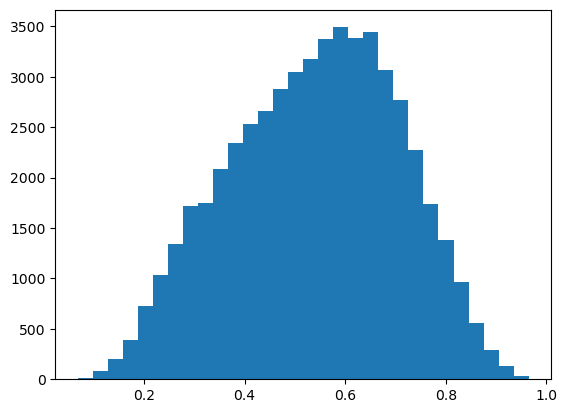

In [ ]:
plt.hist([b for a, b in jsd.results.items()], bins=30)

patients = list(set([a[0] for a, b in jsd.results.items()]))

jsd_ctfinal_df = pd.DataFrame(index=patients, columns=[f'JSD@CT_final@{a[1]}@{a[2]}' for a, b in jsd.results.items()])
for pat, value in jsd.results.items():
    jsd_ctfinal_df.loc[pat[0], f'JSD@CT_final@{pat[1]}@{pat[2]}'] = value
jsd_ctfinal_df

In [11]:
jsd_basects = JSD.Spatial2DDensityCorrelation(adata, 'base_celltypes', 'unique_core')
jsd_basects.computeJSDAllCellTypes()

Computing for TMA_A_A1
Computing for TMA_A_A2
Computing for TMA_A_A3
Computing for TMA_A_A4
Computing for TMA_A_A5
Computing for TMA_A_A6
Computing for TMA_A_A7
Computing for TMA_A_B2
Computing for TMA_A_B3
Computing for TMA_A_B4
Computing for TMA_A_B5
Computing for TMA_A_B6
Computing for TMA_A_B7
Computing for TMA_A_C1
Computing for TMA_A_C2
Computing for TMA_A_C3
Computing for TMA_A_C4
Computing for TMA_A_C5
Computing for TMA_A_C6
Computing for TMA_A_C7
Computing for TMA_A_D1
Computing for TMA_A_D5
Computing for TMA_A_D6
Computing for TMA_A_D7
Computing for TMA_A_E1
Computing for TMA_A_E3
Computing for TMA_A_E4
Computing for TMA_A_E5
Computing for TMA_A_E6
Computing for TMA_A_E7
Computing for TMA_A_F1
Computing for TMA_A_F3
Computing for TMA_A_F4
Computing for TMA_A_F5
Computing for TMA_A_F6
Computing for TMA_A_F7
Computing for TMA_A_G1
Computing for TMA_A_G2
Computing for TMA_A_G3
Computing for TMA_A_G4
Computing for TMA_A_G5
Computing for TMA_A_G6
Computing for TMA_A_G7
Computing f

,JSD@CT_final@B_cells@Tumour,JSD@CT_final@Tumour@B_cells,JSD@CT_final@B_cells@CD4_cells,JSD@CT_final@CD4_cells@B_cells,JSD@CT_final@B_cells@Fibroblast,JSD@CT_final@Fibroblast@B_cells,JSD@CT_final@B_cells@Vessels,JSD@CT_final@Vessels@B_cells,JSD@CT_final@B_cells@Other_Stromal_cells,JSD@CT_final@Other_Stromal_cells@B_cells,...,JSD@CT_final@B_cells@CD8_cells,JSD@CT_final@CD8_cells@B_cells,JSD@CT_final@B_cells@Macrophages,JSD@CT_final@Macrophages@B_cells,JSD@CT_final@CD4_cells@CD8_cells,JSD@CT_final@CD8_cells@CD4_cells,JSD@CT_final@CD4_cells@Macrophages,JSD@CT_final@Macrophages@CD4_cells,JSD@CT_final@CD8_cells@Macrophages,JSD@CT_final@Macrophages@CD8_cells
TMA_A_F7,0.887054,0.887054,0.827318,0.827318,0.821948,0.821948,0.768677,0.768677,0.841829,0.841829,...,0.883611,0.883611,0.888344,0.888344,0.259357,0.259357,0.37085,0.37085,0.257131,0.257131
TMA_A_I3,0.765149,0.765149,0.564204,0.564204,0.764106,0.764106,0.743141,0.743141,0.772057,0.772057,...,0.590169,0.590169,0.615565,0.615565,0.326361,0.326361,0.234451,0.234451,0.251893,0.251893
TMA_B_C8,0.626799,0.626799,0.532187,0.532187,0.590324,0.590324,0.605437,0.605437,0.562629,0.562629,...,0.574185,0.574185,0.584853,0.584853,0.165598,0.165598,0.19885,0.19885,0.160778,0.160778
TMA_A_J2,0.626306,0.626306,0.493857,0.493857,0.624929,0.624929,0.539961,0.539961,0.594929,0.594929,...,0.501722,0.501722,0.522454,0.522454,0.287726,0.287726,0.287727,0.287727,0.185406,0.185406
TMA_A_A2,0.807163,0.807163,0.503786,0.503786,0.641513,0.641513,0.629478,0.629478,0.631078,0.631078,...,0.670321,0.670321,0.68448,0.68448,0.304315,0.304315,0.298157,0.298157,0.173273,0.173273
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TMA_B_G7,0.598622,0.598622,0.473654,0.473654,0.536499,0.536499,0.552601,0.552601,0.605491,0.605491,...,0.457663,0.457663,0.573348,0.573348,0.104758,0.104758,0.219995,0.219995,0.194564,0.194564
TMA_B_H5,0.609692,0.609692,0.293311,0.293311,0.509426,0.509426,0.639716,0.639716,0.429348,0.429348,...,0.36082,0.36082,0.426812,0.426812,0.133584,0.133584,0.260167,0.260167,0.217802,0.217802
TMA_A_A7,0.459431,0.459431,0.284453,0.284453,0.433144,0.433144,0.387754,0.387754,0.354752,0.354752,...,0.319857,0.319857,0.376039,0.376039,0.189897,0.189897,0.250305,0.250305,0.198843,0.198843
TMA_A_E4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.246408,0.246408,0.349566,0.349566,0.423745,0.423745


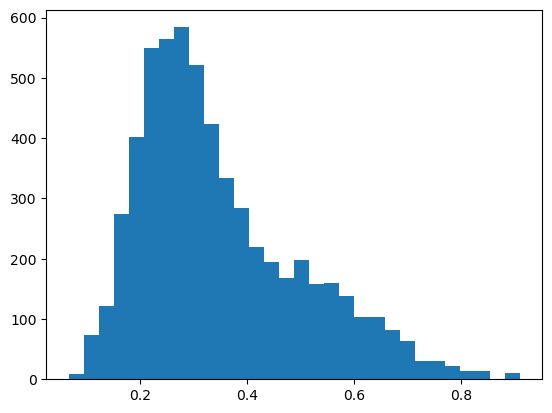

In [ ]:
plt.hist([b for a, b in jsd_basects.results.items()], bins=30)

patients = list(set([a[0] for a, b in jsd_basects.results.items()]))

jsd_basect_df = pd.DataFrame(index=patients, columns=[f'JSD@CT_final@{a[1]}@{a[2]}' for a, b in jsd_basects.results.items()])
for pat, value in jsd_basects.results.items():
    jsd_basect_df.loc[pat[0], f'JSD@CT_final@{pat[1]}@{pat[2]}'] = value
jsd_basect_df

In [13]:
gcrossdf1 = pd.DataFrame(data=adata.uns['CT_final_gcross_auc'], columns=['GCross:CT_final:' + a for a in adata.uns['CT_final_gcross_auc_labels']], \
                                                                         index=sorted(adata.obs['unique_core'].unique()))
gcrossdf2 = pd.DataFrame(data=adata.uns['Metabolic_baseCT_gcross_auc'], columns=['GCross:Metabolic_baseCT:' + a for a in adata.uns['Metabolic_baseCT_gcross_auc_labels']], \
                                                                                 index=sorted(adata.obs['unique_core'].unique()))
gcrossdf3 = pd.DataFrame(data=adata.uns['base_celltypes_gcross_auc'], columns=['GCross:base_celltypes:' + a for a in adata.uns['base_celltypes_gcross_auc_labels']], \
                         index=sorted(adata.obs['unique_core'].unique()))
gcrossdf = pd.concat([gcrossdf1, gcrossdf2, gcrossdf3], axis=1)

In [14]:
from spatial_analysis.utils import ObsHelper

nb_cols = ['nb_tumour_nontumour_20_3', 'nb_tumour_nontumour_50_2']
ct_cols = ['CT_basetumour', 'CT_final', 'CT_metatumour_funcimmu', 'Metabolic_allcells', 'Metabolic_baseCT_filtered', 'structural_immune_tumour_functional']

def calculatepropsinnbs(adata, nb_col, ct_col, sample_id):
    agg_helper = ObsHelper(adata, [nb_col, sample_id]) # By core + neighborhood operations
    df= agg_helper.get_metadata_df(ct_col, skey_handle="category_proportions")
    df = df.reset_index().melt(id_vars=[sample_id, nb_col],value_vars=set(adata.obs[ct_col])).pivot(index=sample_id, columns = [ct_col,nb_col], values = 'value').fillna(0)
    df = single_index(df)
    return df

def single_index(data):
    single_indexed = data.columns.map(lambda x: ":".join(x))
    data.columns = single_indexed
    return data

nbproportions = {}
for nb in nb_cols:
    for ct in ct_cols:
        nbproportions[f"{nb}:{ct}"] = calculatepropsinnbs(adata, nb, ct, sample_id ='unique_core')

In [15]:
for key in nbproportions.keys():
    nb_temp1 = nbproportions[key]
    nb_temp1.index = nb_temp1.index.astype(str)
    val = key.split(':')[1]
    nb_temp1.columns = [f'nb:{val}' + a if a != 'unique_core' else a for a in nb_temp1.columns]

dfPatientAnnData = pd.concat([gcrossdf, jsd_basect_df, jsd_ctfinal_df, nb_temp1], axis=1)

In [16]:
dfPatientAnnData['patientID'] = dfPatientAnnData.index.map(adata.obs.groupby(by='patientID').first()[['adjtma_PCF_repA']].reset_index().set_index('adjtma_PCF_repA').to_dict()['patientID'])
dfPatientAnnData.loc[dfPatientAnnData['patientID'].isna(), 'patientID'] = dfPatientAnnData.loc[dfPatientAnnData['patientID'].isna(), :].index.map(adata.obs.groupby(by='patientID').first()[['adjtma_PCF_repB']].reset_index().set_index('adjtma_PCF_repB').to_dict()['patientID'])
dfPatientAnnData['Relapse_status'] = dfPatientAnnData['patientID'].map(adata.obs.groupby(by='patientID').first()[['Relapse_status']].to_dict()['Relapse_status'])
dfPatientAnnData['Relapse_followup'] = dfPatientAnnData['patientID'].map(adata.obs.groupby(by='patientID').first()[['Relapse_followup']].to_dict()['Relapse_followup'])
dfPatientAnnData['Histology'] = dfPatientAnnData['patientID'].map(adata.obs.groupby(by='patientID').first()[['Histology']].to_dict()['Histology'])

/var/folders/fv/sc58rjq1711g81jhlrb4z7t40000gn/T/ipykernel_36373/3350725016.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfPatientAnnData['patientID'] = dfPatientAnnData.index.map(adata.obs.groupby(by='patientID').first()[['adjtma_PCF_repA']].reset_index().set_index('adjtma_PCF_repA').to_dict()['patientID'])
/var/folders/fv/sc58rjq1711g81jhlrb4z7t40000gn/T/ipykernel_36373/3350725016.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dfPatientAnnData.loc[dfPatientAnnData['patientID'].isna(), 'patientID'] = dfPatientAnnData.loc[dfPatientAnnData['patientID'].isna(), :].index.map(adata.obs.groupby(by='pat

In [17]:
dfPatientAnnData_LUAD = dfPatientAnnData[(dfPatientAnnData['Histology'] == 'Adenocarcinoma') & (dfPatientAnnData['Relapse_status'] != '#VALUE!')]

dfPatientAnnData_LUAD = dfPatientAnnData_LUAD.loc[:,~dfPatientAnnData_LUAD.columns.duplicated()].copy()

In [20]:
dfPatientAnnData_LUAD = dfPatientAnnData_LUAD.loc[:,dfPatientAnnData_LUAD.columns != 'Relapse_followup']
dfPatientAnnData_LUAD

,GCross:CT_final:B_cells_@_to_@_B_cells,GCross:CT_final:B_cells_@_to_@_CD44+,GCross:CT_final:B_cells_@_to_@_CD44+_PDL1+,GCross:CT_final:B_cells_@_to_@_CD4_TFH,GCross:CT_final:B_cells_@_to_@_CD4_cells,GCross:CT_final:B_cells_@_to_@_CD8_cells,GCross:CT_final:B_cells_@_to_@_Cytotoxic_CD8_cells,GCross:CT_final:B_cells_@_to_@_Fibroblast,GCross:CT_final:B_cells_@_to_@_MHC_I,GCross:CT_final:B_cells_@_to_@_MHC_I&II,...,nb:structural_immune_tumour_functionalTumourCell_PDL1_HLADR:Tumour,nb:structural_immune_tumour_functionalTumourCell_HLADR_HLAA:Stroma,nb:structural_immune_tumour_functionalTumourCell_HLADR_HLAA:Tumour,nb:structural_immune_tumour_functionalStructuralCell_PDL1_HLAA:Stroma,nb:structural_immune_tumour_functionalStructuralCell_PDL1_HLAA:Tumour,nb:structural_immune_tumour_functionalStructuralCell_PDL1_PD1_GRZMB:Stroma,nb:structural_immune_tumour_functionalStructuralCell_PDL1_PD1_GRZMB:Tumour,patientID,Relapse_status,Histology
TMA_A_A1,NaN,152.500000,NaN,NaN,442.500000,407.500000,NaN,477.500000,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,B43,0.0,Adenocarcinoma
TMA_A_A3,410.278402,173.277356,NaN,432.380336,480.450102,422.354514,NaN,461.706622,209.722146,431.574550,...,0.000000,0.005036,0.004301,0.000000,0.000000,0.000000,0.000688,B32,1.0,Adenocarcinoma
TMA_A_A4,454.722902,NaN,NaN,474.585187,484.338594,435.916967,344.187853,470.578351,339.541904,325.001611,...,0.001013,0.000000,0.000000,0.000336,0.000000,0.003581,0.002026,B27,0.0,Adenocarcinoma
TMA_A_A7,470.036680,NaN,NaN,467.037067,481.631248,470.054998,405.550093,454.357501,390.991007,356.961244,...,0.000000,0.000454,0.000357,0.003068,0.000178,0.000227,0.000357,B11,1.0,Adenocarcinoma
TMA_A_B3,483.487255,268.948235,NaN,458.186900,477.148317,455.593010,309.207500,436.626225,168.253006,379.387752,...,0.000000,0.000265,0.001335,0.000000,0.000000,0.001059,0.000763,B32,1.0,Adenocarcinoma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TMA_B_J2,320.762880,433.805838,112.386836,NaN,463.670546,471.529575,NaN,481.751343,182.363011,NaN,...,0.000000,0.000000,0.000000,0.000409,0.000000,0.000000,0.000234,B81,1.0,Adenocarcinoma
TMA_B_J3,316.387293,429.563981,355.928055,342.377513,474.452651,473.060428,351.240758,442.815450,371.086561,NaN,...,0.001777,0.000000,0.000000,0.010211,0.002538,0.000000,0.000127,B76,0.0,Adenocarcinoma
TMA_B_J4,434.068085,186.383429,NaN,96.328520,478.179512,475.967355,NaN,479.355990,407.156550,184.682761,...,0.000824,0.000570,0.000000,0.033517,0.007005,0.000285,0.000412,B71,1.0,Adenocarcinoma
TMA_B_J7,483.362621,371.936770,283.773123,395.127464,484.430148,478.152970,128.943721,461.793400,431.861489,351.551859,...,0.000000,0.001581,0.000967,0.010731,0.001128,0.000000,0.000000,B56,0.0,Adenocarcinoma


In [21]:
from sklearn.preprocessing import QuantileTransformer
qt = QuantileTransformer(n_quantiles=dfPatientAnnData_LUAD.shape[0], random_state=0)

cols = dfPatientAnnData_LUAD.columns.isin([
        'patientID', 'Relapse_status', 'Histology'
    ])

dfPatientAnnData_LUAD.loc[:,~cols] = pd.DataFrame(qt.fit_transform(dfPatientAnnData_LUAD.loc[:,~cols]), 
                                       columns=dfPatientAnnData_LUAD.columns[~cols], 
                                       index=dfPatientAnnData_LUAD.index
)

/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [151]:
dfPatientAnnData_LUAD

,GCross:CT_final:B_cells_@_to_@_B_cells,GCross:CT_final:B_cells_@_to_@_CD44+,GCross:CT_final:B_cells_@_to_@_CD44+_PDL1+,GCross:CT_final:B_cells_@_to_@_CD4_TFH,GCross:CT_final:B_cells_@_to_@_CD4_cells,GCross:CT_final:B_cells_@_to_@_CD8_cells,GCross:CT_final:B_cells_@_to_@_Cytotoxic_CD8_cells,GCross:CT_final:B_cells_@_to_@_Fibroblast,GCross:CT_final:B_cells_@_to_@_MHC_I,GCross:CT_final:B_cells_@_to_@_MHC_I&II,...,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalTumourCell_PD1_HLAA:Stroma,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalTumourCell_PD1_HLAA:Tumour,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalImmuneCell_PD1_ICOS_GRZMB:Stroma,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalImmuneCell_PD1_ICOS_GRZMB:Tumour,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalImmuneCell_PDL1_ICOS:Stroma,nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalImmuneCell_PDL1_ICOS:Tumour,patientID,Relapse_status,Relapse_followup,Histology
TMA_A_A1,NaN,0.030143,NaN,NaN,0.039552,0.038605,NaN,0.814103,NaN,NaN,...,0.000000,0.000000,0.846154,0.551282,0.000000,0.000000,B43,0.0,1968,Adenocarcinoma
TMA_A_A3,0.232191,0.048699,NaN,0.675866,0.604526,0.053495,NaN,0.304796,0.153513,0.790977,...,0.910256,0.910256,0.487179,0.307692,0.000000,0.000000,B32,1.0,233,Adenocarcinoma
TMA_A_A4,0.431693,NaN,NaN,0.964368,0.920684,0.067244,0.473832,0.582004,0.347253,0.311748,...,0.846154,0.871795,0.448718,0.884615,0.500000,0.987179,B27,0.0,1204,Adenocarcinoma
TMA_A_A7,0.575504,NaN,NaN,0.933391,0.689866,0.333333,0.835317,0.121574,0.488808,0.437994,...,0.756410,0.897436,0.397436,0.641026,0.756410,0.000000,B11,1.0,371,Adenocarcinoma
TMA_A_B3,0.936164,0.160922,NaN,0.842976,0.407638,0.113438,0.311689,0.013716,0.083453,0.545339,...,0.961538,0.884615,0.923077,0.000000,0.000000,0.000000,B32,1.0,233,Adenocarcinoma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TMA_B_J2,0.061179,0.885608,0.128612,NaN,0.174755,0.412267,NaN,0.947459,0.101986,NaN,...,0.000000,0.000000,0.756410,0.769231,0.923077,0.692308,B81,1.0,2262,Adenocarcinoma
TMA_B_J3,0.051030,0.809957,0.868175,0.249221,0.352663,0.539403,0.528535,0.027844,0.438954,NaN,...,0.000000,0.000000,0.089744,0.256410,0.000000,0.000000,B76,0.0,995,Adenocarcinoma
TMA_B_J4,0.311646,0.062899,NaN,0.034352,0.461655,0.640567,NaN,0.915012,0.623380,0.046933,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,B71,1.0,214,Adenocarcinoma
TMA_B_J7,0.921807,0.489692,0.574173,0.475513,0.931458,0.757518,0.102572,0.311378,0.859735,0.397233,...,0.000000,0.000000,0.102564,0.282051,0.000000,0.000000,B56,0.0,2558,Adenocarcinoma


In [ ]:
meta_cols = ['patientID', 'Relapse_status', 'Histology']

X_raw = dfPatientAnnData_LUAD.loc[:, ~dfPatientAnnData_LUAD.columns.isin(meta_cols)].copy()

Y = dfPatientAnnData_LUAD[['Relapse_status', ]]

patient_groups = dfPatientAnnData_LUAD['patientID'].values

n_cores    = X_raw.shape[0]
n_patients = len(np.unique(patient_groups))
print(f"LUAD cohort: {n_cores} TMA cores from {n_patients} unique patients")
print(f"Event rate: {Y['Relapse_status'].mean():.1%}")

LUAD cohort: 81 TMA cores from 45 unique patients
Event rate: 46.9%


In [25]:
X_raw

,GCross:CT_final:B_cells_@_to_@_B_cells,GCross:CT_final:B_cells_@_to_@_CD44+,GCross:CT_final:B_cells_@_to_@_CD44+_PDL1+,GCross:CT_final:B_cells_@_to_@_CD4_TFH,GCross:CT_final:B_cells_@_to_@_CD4_cells,GCross:CT_final:B_cells_@_to_@_CD8_cells,GCross:CT_final:B_cells_@_to_@_Cytotoxic_CD8_cells,GCross:CT_final:B_cells_@_to_@_Fibroblast,GCross:CT_final:B_cells_@_to_@_MHC_I,GCross:CT_final:B_cells_@_to_@_MHC_I&II,...,nb:structural_immune_tumour_functionalImmuneCell_PD1_HLAA_ICOS_GRZMB:Stroma,nb:structural_immune_tumour_functionalImmuneCell_PD1_HLAA_ICOS_GRZMB:Tumour,nb:structural_immune_tumour_functionalTumourCell_PDL1_HLADR:Stroma,nb:structural_immune_tumour_functionalTumourCell_PDL1_HLADR:Tumour,nb:structural_immune_tumour_functionalTumourCell_HLADR_HLAA:Stroma,nb:structural_immune_tumour_functionalTumourCell_HLADR_HLAA:Tumour,nb:structural_immune_tumour_functionalStructuralCell_PDL1_HLAA:Stroma,nb:structural_immune_tumour_functionalStructuralCell_PDL1_HLAA:Tumour,nb:structural_immune_tumour_functionalStructuralCell_PDL1_PD1_GRZMB:Stroma,nb:structural_immune_tumour_functionalStructuralCell_PDL1_PD1_GRZMB:Tumour
TMA_A_A1,NaN,0.029223,NaN,NaN,0.038532,0.037636,NaN,0.818750,NaN,NaN,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
TMA_A_A3,0.256610,0.047263,NaN,0.685483,0.601839,0.052102,NaN,0.296670,0.149318,0.800000,...,0.0000,0.0000,0.8000,0.0000,0.7750,0.8000,0.0000,0.0000,0.0000,0.8875
TMA_A_A4,0.448251,NaN,NaN,0.965415,0.922740,0.065488,0.461745,0.566602,0.337916,0.319205,...,0.8375,0.9375,0.6125,0.8125,0.0000,0.0000,0.4625,0.0000,0.9500,0.9625
TMA_A_A7,0.586907,NaN,NaN,0.935761,0.697959,0.337992,0.839496,0.118375,0.475119,0.440686,...,0.8875,0.8375,0.0000,0.0000,0.4375,0.5000,0.7125,0.5875,0.6000,0.7750
TMA_A_B3,0.937927,0.155885,NaN,0.847859,0.397067,0.110540,0.303714,0.013350,0.080689,0.543308,...,0.6625,0.0000,0.0000,0.0000,0.4000,0.6750,0.0000,0.0000,0.8000,0.9000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TMA_B_J2,0.058376,0.875370,0.126337,NaN,0.170130,0.414521,NaN,0.948809,0.098885,NaN,...,0.7375,0.0000,0.0000,0.0000,0.0000,0.0000,0.4875,0.0000,0.0000,0.7000
TMA_B_J3,0.049728,0.800000,0.867628,0.257794,0.343360,0.538404,0.514017,0.027095,0.425679,NaN,...,0.0000,0.0000,0.0000,0.8500,0.0000,0.0000,0.8750,0.8375,0.0000,0.6125
TMA_B_J4,0.337643,0.060660,NaN,0.033296,0.450074,0.636988,NaN,0.917252,0.601810,0.044920,...,0.0000,0.0000,0.8375,0.8000,0.5125,0.0000,0.9625,0.9000,0.6375,0.7875
TMA_B_J7,0.924021,0.475840,0.573930,0.476305,0.933274,0.750982,0.100007,0.303135,0.863518,0.400000,...,0.4750,0.0000,0.7375,0.0000,0.6625,0.6125,0.8875,0.7375,0.0000,0.0000


# Feature selection

Defines and fits preprocessing pipelines.

In [26]:
# ── Preprocessing — defined but NOT yet fitted ────────────────────────────────
preprocessing = Pipeline(
    steps=[
        #("variance", VarianceThreshold(0.0)),
        ("lif",      LowInfoFilter(max_nan_fraction=0.6)),
        ("impute",   SimpleImputer(strategy="median")),
        ("std",      StandardScaler()),
    ]
)

In [27]:
preprocessing.fit_transform(X_raw)

/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


array([[ 1.06700308e-03, -1.77860361e+00, -5.04055831e-03, ...,
        -8.92959260e-01, -9.95728210e-01, -8.14091012e-01],
       [-9.21893093e-01, -1.71042362e+00,  7.13216516e-01, ...,
        -8.92959260e-01, -9.95728210e-01,  1.40268806e+00],
       [-1.97382245e-01, -6.43141394e-03,  1.78804944e+00, ...,
        -8.92959260e-01,  1.45713408e+00,  1.59002151e+00],
       ...,
       [-6.15541521e-01, -1.65979066e+00, -1.79093948e+00, ...,
         1.37719698e+00,  6.50271484e-01,  1.15291014e+00],
       [ 1.60129133e+00, -9.06597868e-02, -8.99502498e-02, ...,
         9.67307655e-01, -9.95728210e-01, -8.14091012e-01],
       [ 8.96205057e-01,  1.19989641e+00, -1.43229809e+00, ...,
         1.25107718e+00, -9.95728210e-01, -8.14091012e-01]],
      shape=(81, 11867))

In [ ]:
splitter = RepeatedStratifiedKFold(
    n_splits=4,
    n_repeats=5,
    random_state=random_state,
)

n_folds = splitter.get_n_splits(X_raw, Y, groups=patient_groups)
print(f"Total CV folds: {n_folds}  (n_splits × n_repeats = 4 × 2)")

Total CV folds: 20  (n_splits × n_repeats = 4 × 2)


# Feature Selection across whole cohort 

In [ ]:
preprocessing = Pipeline(
    steps=[
        ('variance_threshold', VarianceThreshold(threshold=0.0)),
        ('low_info_filter', LowInfoFilter(max_nan_fraction=0.1)),
        ('imputer', SimpleImputer(strategy='median')),
        ('std', StandardScaler())
    ]
)

preprocessing.fit(X_raw)
pre_X_all = pd.DataFrame(preprocessing.transform(X_raw), columns=preprocessing.get_feature_names_out(X_raw.columns), index=X_raw.index)

/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/feature_selection/_variance_threshold.py:114: RuntimeWarning: Degrees of freedom <= 0 for slice.
  self.variances_ = np.nanvar(X, axis=0)
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/feature_selection/_variance_threshold.py:122: RuntimeWarning: All-NaN slice encountered
  self.variances_ = np.nanmin(compare_arr, axis=0)
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  

In [ ]:
stabl_regression = Stabl(
    base_estimator=ALasso(),
    lambda_grid={'alpha': np.geomspace(1e-5, 1e-1, 20), },
    n_lambda=30,
    artificial_type="knockoff",
    artificial_proportion=1,
    n_bootstraps=200,
    random_state=42,
    verbose=1,
)

stabl_regression.fit(pre_X_all, Y)

/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Stabl progress:   0%|          | 0/20 [00:00<?, ?it/s]

Stabl(artificial_proportion=1, artificial_type='knockoff',
      base_estimator=ALasso(),
      fdr_threshold_range=array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.4...
      lambda_grid={'alpha': array([1.00000000e-05, 1.62377674e-05, 2.63665090e-05, 4.28133240e-05,
       6.95192796e-05, 1.12883789e-04, 1.83298071e-04, 2.97635144e-04,
       4.83293024e-04, 7.84759970e-04, 1.27427499e-03, 2.06913808e-03,
       3.35981829e-03, 5.45559478e-03, 8.85866790e-03, 1.43844989e-02,
       2.33572147e-02, 3.79269019e-02, 6.15848211e-02, 1.00000000e-01])},
      n_bootstraps=200, n_lambda=30, random_state=42, verbose=1)

(<Figure size 600x400 with 1 Axes>, <Axes: xlabel='Threshold'>)

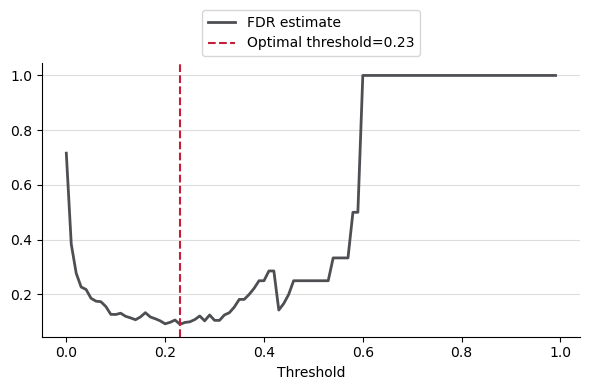

In [37]:
from stabl.stabl import Stabl, plot_stabl_path, plot_fdr_graph

plot_fdr_graph(stabl_regression, figsize=(6, 4))

(<Figure size 400x800 with 1 Axes>,
 <Axes: xlabel='$\\lambda$', ylabel='Frequency of selection'>,
 [np.float64(1.0),
  np.float64(0.6158482110660268),
  np.float64(0.3792690190732254),
  np.float64(0.23357214690901215),
  np.float64(0.1438449888287663),
  np.float64(0.08858667904100832),
  np.float64(0.054555947811685206),
  np.float64(0.03359818286283781),
  np.float64(0.0206913808111479),
  np.float64(0.01274274985703135),
  np.float64(0.007847599703514615),
  np.float64(0.004832930238571753),
  np.float64(0.0029763514416313195),
  np.float64(0.0018329807108324375),
  np.float64(0.0011288378916846896),
  np.float64(0.0006951927961775606),
  np.float64(0.0004281332398719396),
  np.float64(0.0002636650898730361),
  np.float64(0.00016237767391887227),
  np.float64(0.0001)],
 [np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(3),
  np.int64(4),
  np.int64(5),
  np.int64(6),
  np.int64(7),
  np.int64(8),
  np.int64(9),
  np.int64(10),
  np.int64(11),
  np.int64(12),
  np.int64(13),
 

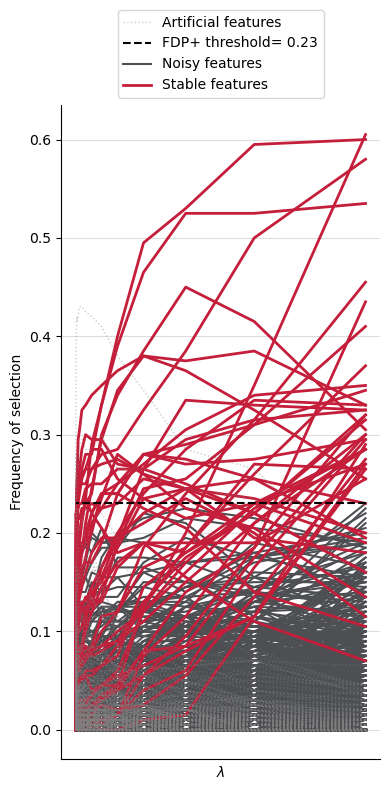

In [38]:
plot_stabl_path(stabl_regression, figsize=(4,8))

In [49]:
selected_features = stabl_regression.get_feature_names_out()
selected_features

array(['GCross:CT_final:B_cells_@_to_@_Fibroblast',
       'GCross:CT_final:B_cells_@_to_@_Macrophages_M2',
       'GCross:CT_final:B_cells_@_to_@_Vessels',
       'GCross:CT_final:CD44+_@_to_@_CD4_cells',
       'GCross:CT_final:CD44+_@_to_@_Vessels',
       'GCross:CT_final:CD4_TFH_@_to_@_CD8_cells',
       'GCross:CT_final:CD4_TFH_@_to_@_Fibroblast',
       'GCross:CT_final:CD4_cells_@_to_@_CD4_cells',
       'GCross:CT_final:CD8_cells_@_to_@_Tumour',
       'GCross:CT_final:MHC_II_@_to_@_Other_Stromal_cells',
       'GCross:CT_final:Macrophages_@_to_@_CD4_cells',
       'GCross:CT_final:Macrophages_M2_@_to_@_Macrophages',
       'GCross:CT_final:Tumour_@_to_@_CD44+',
       'GCross:CT_final:Tumour_@_to_@_Other_Stromal_cells',
       'GCross:CT_final:Tumour_@_to_@_Tumour',
       'GCross:Metabolic_baseCT:CD4_cellsGlutamine_import_@_to_@_CD4_cellsGlutamine_import',
       'GCross:Metabolic_baseCT:CD4_cellsLipid_Oxidation_@_to_@_MacrophagesLipid_Oxidation',
       'GCross:Metabolic_ba

In [44]:
#import importlib
#import cox_cv_pipeline
#importlib.reload(cox_cv_pipeline)
#from stabl import 
#
#cv_results_corrected = stabl_cv(
#    x_data=X_raw,                          # raw, unscaled features
#    y_data=Y,
#    fold_splitter=splitter,
#    model=stabl_regression,
#    fold_groups=patient_groups,            # FIX 1: patient-level grouping
#    preprocessing_pipeline=preprocessing,  # FIX 2: fit preprocessing per fold
#    save_path='stabl_recurrencestatus',
#    override=False,
#    redo_preprocessing_on_test=False,      # test fold uses train-fold statistics
#    differnet_penalty_factors=False,
#)

In [45]:
#cv_results_corrected.to_csv('correctedCVPipeline.csv')
#cv_results_corrected

## Final model evaluation

In [50]:
top_features = selected_features
X_top = X_raw[top_features]

missing = [f for f in top_features if f not in X_raw.columns]
if missing:
    print(f"WARNING: {len(missing)} features not found in X_raw and will be dropped: {missing}")
    top_features = [f for f in top_features if f not in missing]

print(f"Using {len(top_features)} features for the final models:\n")

Using 44 features for the final models:



In [372]:
top_features

['GCross:CT_final:B_cells_@_to_@_CD4_cells',
 'GCross:CT_final:B_cells_@_to_@_Fibroblast',
 'GCross:CT_final:B_cells_@_to_@_Macrophages',
 'GCross:CT_final:B_cells_@_to_@_Other_Stromal_cells',
 'GCross:CT_final:B_cells_@_to_@_Tumour',
 'GCross:CT_final:B_cells_@_to_@_Vessels',
 'GCross:CT_final:CD44+_@_to_@_CD8_cells',
 'GCross:CT_final:B_cells_@_to_@_CD8_cells',
 'GCross:CT_final:CD44+_@_to_@_Other_Stromal_cells',
 'GCross:CT_final:CD44+_@_to_@_CD4_cells',
 'GCross:CT_final:CD44+_@_to_@_Tumour',
 'GCross:CT_final:CD4_cells_@_to_@_Other_Stromal_cells',
 'GCross:CT_final:CD4_cells_@_to_@_CD4_cells',
 'GCross:CT_final:CD4_TFH_@_to_@_CD8_cells',
 'GCross:CT_final:CD8_cells_@_to_@_Fibroblast',
 'GCross:CT_final:CD8_cells_@_to_@_CD8_cells',
 'GCross:CT_final:Tumour_@_to_@_CD4_cells',
 'nb:structural_immune_tumour_functionalnb:structural_immune_tumour_functionalTumourCell_PDL1_PD1_HLAA_ICOS_GRZMB:Tumour',
 'GCross:CT_final:CD44+_@_to_@_Fibroblast',
 'GCross:CT_final:CD8_cells_@_to_@_CD4_cell

### Cross-validation evaluation

In [64]:
Y_surv = sksurv.util.Surv().from_dataframe(data=dfPatientAnnData[(dfPatientAnnData['Histology'] == 'Adenocarcinoma') & (dfPatientAnnData['Relapse_followup'] != '#VALUE!')].loc[
    X_raw.index[X_raw.index.isin(dfPatientAnnData[(dfPatientAnnData['Histology'] == 'Adenocarcinoma') & (dfPatientAnnData['Relapse_followup'] != '#VALUE!')].index)], :]
    .rename(columns={'Relapse_status': 'event', 'Relapse_followup': 'time'}), 
    event='event', time='time')

X_surv = dfPatientAnnData[(dfPatientAnnData['Histology'] == 'Adenocarcinoma') & (dfPatientAnnData['Relapse_followup'] != '#VALUE!')]

patient_groups_surv = dfPatientAnnData[['patientID']].loc[X_surv.index, :].values
Y_surv

array([(False, 1968.), ( True,  233.), (False, 1204.), ( True,  371.),
       ( True,  233.), (False, 1204.), ( True,  371.), (False, 2157.),
       ( True,  734.), (False, 1291.), (False, 1156.), ( True,  699.),
       ( True,  301.), (False, 2157.), (False, 1156.), ( True,  699.),
       ( True,  301.), (False, 1771.), (False, 1100.), ( True,  613.),
       (False, 1771.), (False, 1100.), ( True,  613.), ( True,  385.),
       (False, 1843.), (False, 1555.), (False, 1097.), ( True,  310.),
       (False,  930.), ( True,  385.), (False, 1097.), ( True,  310.),
       (False,  930.), ( True,  345.), ( True,  644.), ( True,  426.),
       (False, 1072.), (False,  852.), ( True,  345.), ( True,  426.),
       (False, 1072.), (False,  852.), ( True,  800.), (False,  297.),
       (False, 2239.), ( True,  800.), (False,  297.), (False, 2239.),
       ( True,  466.), (False,  249.), (False, 2454.), (False, 1687.),
       ( True,  466.), ( True,  267.), (False, 2454.), (False, 1687.),
      

In [ ]:
# Parameter optimisation of Random Survival Forest Model via grid search

class SurvivalStratifiedGroupRepeatedKFold(
    SurvivalStratifyMixin,
    StrictGroupMixin,
    RepeatedStratifiedKFold,
):
    """
    Repeated stratified K-fold that splits at the *patient* level.

    - Groups (patient IDs) are kept intact: both TMA cores of the same patient
      always end up in the same fold.
    - Stratification is by event-observed status, so the event rate is balanced
      across folds even with the group constraint.
    - Works with scikit-survival structured arrays for Y directly.

    Usage
    -----
    splitter = SurvivalStratifiedGroupRepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
    for train_idx, test_idx in splitter.split(X, Y, groups=patient_ids):
        ...
    """
    pass

param_grid = ParameterGrid({
    "n_estimators"    : [100, 300, 500, 1000],
    "min_samples_leaf": [1, 3, 5, 10],      # controls tree depth implicitly
    "max_features"    : ["sqrt", "log2", 0.5],  # features considered per split
    "max_samples"     : [0.5, 0.7, None], # bootstrap subsample fraction
})

# Final CV evaluation (same patient-grouped splitter as STABL CV)
final_splitter = SurvivalStratifiedGroupRepeatedKFold(
    n_splits=4, n_repeats=10, random_state=random_state
)


best_c, best_params = 0, None
for train_idx, test_idx in final_splitter.split(X_surv[selected_features], Y_surv, groups=patient_groups_surv):
    X_tr_raw  = X_surv[selected_features].iloc[train_idx]
    X_te_raw  = X_surv[selected_features].iloc[test_idx]
    X_tr_full = X_surv[selected_features].iloc[train_idx]   # full columns for nb feature lookup
    Y_tr      = Y_surv[train_idx]
    Y_te      = Y_surv[test_idx]
    for params in param_grid:
        scale = StandardScaler().fit(X_tr_raw)
        X_tr_raw = pd.DataFrame(scale.transform(X_tr_raw), index=X_tr_raw.index, columns=X_tr_raw.columns)
        X_te_raw = pd.DataFrame(scale.transform(X_te_raw), index=X_te_raw.index, columns=X_te_raw.columns)

        m = RandomSurvivalForest(n_jobs=-1,
                                 random_state=random_state,
                                 **params)
        m.fit(X_tr_raw, Y_tr)
        c = concordance_index_censored(
                Y_te["event"], Y_te["time"], m.predict(X_te_raw)
            )[0]
        if c > best_c:
            best_c, best_params = c, params

print(f"Best test C: {best_c:.4f}", best_params)

/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:86: UserWarning: The groups parameter is ignored by SurvivalStratifiedGroupRepeatedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


Best test C: 0.9313 {'max_features': 'sqrt', 'max_samples': 0.5, 'min_samples_leaf': 5, 'n_estimators': 1000}


In [ ]:
# Paramter optimisation via Gradient Boosting Survival modelling

param_grid = ParameterGrid({
    "learning_rate": [0.01, 0.1, 1.0],
    "n_estimators": [100, 500, 1000],
    "subsample": [0.5, 1.0],
})

final_splitter = SurvivalStratifiedGroupRepeatedKFold(
    n_splits=4, n_repeats=2, random_state=random_state
)
X_here = pd.DataFrame(preprocessing.fit_transform(X_surv[selected_features]), index=X_surv[selected_features].index, columns=preprocessing.get_feature_names_out())


splits = list(final_splitter.split(X_here, Y_surv, groups=patient_groups_surv))

best_c, best_params_gb = 0, None
for params in param_grid:
    fold_cs = []
    for train_idx, test_idx in splits:
        X_tr_raw  = X_here.iloc[train_idx]
        X_te_raw  = X_here.iloc[test_idx]
        Y_tr      = Y_surv[train_idx]
        Y_te      = Y_surv[test_idx]

        scale = StandardScaler().fit(X_tr_raw)
        X_tr_sc = pd.DataFrame(scale.transform(X_tr_raw), index=X_tr_raw.index, columns=X_tr_raw.columns)
        X_te_sc = pd.DataFrame(scale.transform(X_te_raw), index=X_te_raw.index, columns=X_te_raw.columns)

        m = sksurv.ensemble.ComponentwiseGradientBoostingSurvivalAnalysis(
            random_state=random_state, **params
        )
        m.fit(X_tr_sc, Y_tr)
        c = concordance_index_censored(
                Y_te["event"], Y_te["time"], m.predict(X_te_sc)
            )[0]
        fold_cs.append(c)
    mean_c = float(np.mean(fold_cs))
    if mean_c > best_c:
        best_c, best_params_gb = mean_c, params

print(f"Best CV mean C: {best_c:.4f}", best_params_gb)


/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:86: UserWarning: The groups parameter is ignored by SurvivalStratifiedGroupRepeatedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgal

Best CV mean C: 0.5849 {'learning_rate': 1.0, 'n_estimators': 500, 'subsample': 0.5}


In [ ]:
# 

thresh_fold_c   = []
standard_fold_c = []
gbsa_fold_c     = []

oof_thresh_risk   = np.zeros(len(X_raw))
oof_standard_risk = np.zeros(len(X_raw))
oof_gbsa_risk     = np.zeros(len(X_raw))
oof_counts        = np.zeros(len(X_raw), dtype=int)

gbsa_fold_importances = []

final_splitter = SurvivalStratifiedGroupRepeatedKFold(
    n_splits=4, n_repeats=5, random_state=random_state
)

for train_idx, test_idx in final_splitter.split(X_surv[selected_features], Y_surv, groups=patient_groups_surv):
    X_tr_raw  = X_surv[selected_features].iloc[train_idx]
    X_te_raw  = X_surv[selected_features].iloc[test_idx]
    Y_tr      = Y_surv[train_idx]
    Y_te      = Y_surv[test_idx]

    # Standard CoxPH 
    imputer = SimpleImputer(strategy="median")
    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(imputer.fit_transform(X_tr_raw))
    X_te_sc = scaler.transform(imputer.transform(X_te_raw))

    m = RandomSurvivalForest(n_jobs=-1,
                                 random_state=random_state,
                                 **best_params)
    m.fit(X_tr_sc, Y_tr)
    oof_thresh_risk[test_idx] += m.predict(X_te_sc)
    thresh_fold_c.append(m.score(X_te_sc, Y_te))

    try:
        # Lightly regularised
        cox_model = CoxPHSurvivalAnalysis(alpha=0.0001, ties="efron", n_iter=100000, tol=1e-7)
        cox_model.fit(X_tr_sc, Y_tr)
    except:
        continue

    standard_fold_c.append(cox_model.score(X_te_sc, Y_te))
    oof_standard_risk[test_idx] += cox_model.predict(X_te_sc)


    gbsa_model = sksurv.ensemble.ComponentwiseGradientBoostingSurvivalAnalysis(
        random_state=random_state, **best_params_gb
    )
    gbsa_model.fit(X_tr_sc, Y_tr)
    gbsa_fold_c.append(gbsa_model.score(X_te_sc, Y_te))
    oof_gbsa_risk[test_idx] += gbsa_model.predict(X_te_sc)
    gbsa_fold_importances.append(gbsa_model.feature_importances_[1:])

    oof_counts[test_idx] += 1

# Average OOF predictions over repeats
oof_thresh_risk   /= oof_counts
oof_standard_risk /= oof_counts
oof_gbsa_risk     /= oof_counts

thresh_fold_c   = np.array(thresh_fold_c)
standard_fold_c = np.array(standard_fold_c)
gbsa_fold_c     = np.array(gbsa_fold_c)

# Mean GBSA feature importances across all CV folds
gbsa_mean_importances = np.nanmean(gbsa_fold_importances, axis=0)

print(f"CV folds completed       : {len(thresh_fold_c)}")
print(f"OOF counts (min / max)   : {oof_counts.min()} / {oof_counts.max()}  (expected {3})")


/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:86: UserWarning: The groups parameter is ignored by SurvivalStratifiedGroupRepeatedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


CV folds completed       : 20
OOF counts (min / max)   : 0 / 5  (expected 3)


/var/folders/fv/sc58rjq1711g81jhlrb4z7t40000gn/T/ipykernel_36373/1860311430.py:60: RuntimeWarning: invalid value encountered in divide
  oof_thresh_risk   /= oof_counts
/var/folders/fv/sc58rjq1711g81jhlrb4z7t40000gn/T/ipykernel_36373/1860311430.py:61: RuntimeWarning: invalid value encountered in divide
  oof_standard_risk /= oof_counts
/var/folders/fv/sc58rjq1711g81jhlrb4z7t40000gn/T/ipykernel_36373/1860311430.py:62: RuntimeWarning: invalid value encountered in divide
  oof_gbsa_risk     /= oof_counts


### Concordance index with 95 % CI


In [ ]:
def concordance_ci(fold_scores, confidence=0.95):
    n  = len(fold_scores)
    m  = np.mean(fold_scores)
    se = stats.sem(fold_scores)
    lo, hi = stats.t.interval(confidence, df=n - 1, loc=m, scale=se)
    return m, lo, hi

thresh_mean,   thresh_lo,   thresh_hi   = concordance_ci(thresh_fold_c)
standard_mean, standard_lo, standard_hi = concordance_ci(standard_fold_c)
gbsa_mean,     gbsa_lo,     gbsa_hi     = concordance_ci(gbsa_fold_c)

print("=== Final model concordance — 5×3 repeated CV, 95 % CI ===")
print(f"  ThresholdedCoxPH           : {thresh_mean:.3f}  [{thresh_lo:.3f}, {thresh_hi:.3f}]")
print(f"  Standard CoxPH             : {standard_mean:.3f}  [{standard_lo:.3f}, {standard_hi:.3f}]")
print(f"  GradientBoostingSurvival   : {gbsa_mean:.3f}  [{gbsa_lo:.3f}, {gbsa_hi:.3f}]")
print()
print(f"  ThresholdedCoxPH fold scores : {np.round(thresh_fold_c, 3)}")
print(f"  Standard CoxPH   fold scores : {np.round(standard_fold_c, 3)}")
print(f"  GBSA             fold scores : {np.round(gbsa_fold_c, 3)}")


=== Final model concordance — 5×3 repeated CV, 95 % CI ===
  ThresholdedCoxPH           : 0.710  [0.655, 0.765]
  Standard CoxPH             : 0.520  [0.462, 0.578]
  GradientBoostingSurvival   : 0.607  [0.558, 0.655]

  ThresholdedCoxPH fold scores : [0.7   0.779 0.349 0.764 0.761 0.847 0.741 0.541 0.661 0.667 0.757 0.754
 0.736 0.667 0.886 0.619 0.667 0.762 0.85  0.693]
  Standard CoxPH   fold scores : [0.45  0.607 0.368 0.627 0.487 0.26  0.435 0.451 0.488 0.528 0.331 0.574
 0.681 0.6   0.593 0.69  0.434 0.524 0.522 0.75 ]
  GBSA             fold scores : [0.444 0.623 0.66  0.736 0.726 0.467 0.583 0.566 0.479 0.639 0.544 0.557
 0.75  0.543 0.7   0.726 0.45  0.533 0.69  0.714]


### Kaplan-Meier stratification by out-of-fold risk score

Samples are split into **high** and **low** risk groups at the median out-of-fold risk
score (averaged across the 3 CV repeats each sample appears in as a test sample).
Because each prediction is made on held-out data, these KM curves reflect true
out-of-sample discrimination for both models side-by-side.

# KM Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test


def _parse_survival(survival):
    """Accept (durations, events) tuple or sksurv-style structured array."""
    if isinstance(survival, (tuple, list)) and len(survival) == 2:
        d, e = survival
    elif hasattr(survival, "dtype") and survival.dtype.names:
        names = survival.dtype.names
        ev = next((n for n in names if n.lower() in ("event", "status", "cens")), names[0])
        tm = next((n for n in names if n.lower() in ("time", "duration", "t", "tte")), names[1])
        d, e = survival[tm], survival[ev]
    else:
        raise ValueError("survival must be (durations, events) or a structured array")
    return np.asarray(d, dtype=float), np.asarray(e).astype(int)


def km_by_percentile(
    df,
    survival,
    columns,
    percentiles=50,
    ncols=3,
    figsize_per_plot=(4.2, 3.5),
    show_ci=True,
):
    """
    Stratify each column by percentile cutoff(s), plot KM curves, return log-rank p-values.

    Parameters
    ----------
    df : pd.DataFrame
        Source of the stratification columns.
    survival : (durations, events) tuple OR structured array
        Aligned with df rows. events: 1 = event, 0 = censored.
    columns : list of str
        Columns to stratify on (one subplot each).
    percentiles : float or list of float
        Cutoff(s) in [0, 100]. Scalar -> 2 groups; list of k cutoffs -> k+1 groups.
    ncols : int
        Subplot grid width.
    show_ci : bool
        Show 95% pointwise CIs.

    Returns
    -------
    results : dict[col -> {p_value, test_statistic, cutoffs, group_sizes, fitters}]
    fig : matplotlib.figure.Figure
    """
    durations, events = _parse_survival(survival)
    if len(durations) != len(df):
        raise ValueError("survival length does not match df")

    pcts = sorted([percentiles] if np.isscalar(percentiles) else list(percentiles))
    if any(p <= 0 or p >= 100 for p in pcts):
        raise ValueError("percentiles must be strictly between 0 and 100")

    nrows = int(np.ceil(len(columns) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
        squeeze=False,
    )
    axes = axes.ravel()
    results = {}

    for i, col in enumerate(columns):
        ax = axes[i]
        x = df[col].to_numpy()
        mask = ~(pd.isna(x) | pd.isna(durations) | pd.isna(events))
        xv, dv, ev = x[mask], durations[mask], events[mask]

        if len(xv) < 2:
            ax.set_title(f"{col} (insufficient data)"); ax.axis("off"); continue

        cutoffs = np.percentile(xv, pcts)
        groups = np.digitize(xv, cutoffs, right=False)

        if len(pcts) == 1:
            labels = [f"≤ p{pcts[0]:g} ({cutoffs[0]:.3g})", f"> p{pcts[0]:g}"]
        else:
            edges = ["-∞"] + [f"{c:.3g}" for c in cutoffs] + ["+∞"]
            labels = [f"({edges[j]}, {edges[j+1]}]" for j in range(len(edges) - 1)]

        fitters, sizes = [], {}
        for g in np.unique(groups):
            sel = groups == g
            if sel.sum() < 2:
                continue
            label = f"{labels[g]}  n={sel.sum()}, ev={int(ev[sel].sum())}"
            kmf = KaplanMeierFitter(label=label).fit(dv[sel], ev[sel])
            kmf.plot_survival_function(ax=ax, ci_show=show_ci)
            fitters.append(kmf)
            sizes[labels[g]] = int(sel.sum())

        if len(np.unique(groups)) == 2:
            g0, g1 = np.unique(groups)
            test = logrank_test(dv[groups == g0], dv[groups == g1],
                                ev[groups == g0], ev[groups == g1])
        elif len(np.unique(groups)) > 2:
            test = multivariate_logrank_test(dv, groups, ev)
        else:
            test = None

        p = test.p_value if test is not None else np.nan
        stat = test.test_statistic if test is not None else np.nan

        results[col] = {
            "p_value": p, "test_statistic": stat,
            "cutoffs": cutoffs.tolist(), "group_sizes": sizes, "fitters": fitters,
        }
                
        ax.set_title(f"{col}   log-rank p = {p:.3g}")
        ax.set_xlabel("Time"); ax.set_ylabel("Survival probability")
        ax.set_ylim(0, 1.02); ax.legend(fontsize=8, loc="best")


    for j in range(len(columns), len(axes)):
        axes[j].axis("off")
    fig.tight_layout()
    plt.savefig('kms_selected_relapsestatus.svg')


    return results, fig

In [80]:
adata

AnnData object with n_obs × n_vars = 1187511 × 48
    obs: 'Image', 'Object ID', 'Name', 'TMA core', 'Parent', 'ROI', 'x', 'y', 'Nucleus: Area µm^2', 'Nucleus: Length µm', 'Nucleus: Circularity', 'Nucleus: Solidity', 'tumour_nontumour', 'immunecelltypes', 'CD4_type', 'CD8_type', 'mac_type', 'Tumour_type', 'Tumour_type_tidy', 'unique_core', 'patientID', 'adjtma_PCF_repA', 'adjtma_PCF_repB', 'dict', 'DSP_WTA_ROI', 'TNM', 'stage', 'PathwayCode', 'Histology', 'Sex', 'Smoking', 'EndCycle', 'DOB', 'Date of surgery', 'StartDate', 'Deceased', 'DateDeceased', 'Relapse', 'Date of relapse', 'Molecular profile', 'Mutation', 'Last known contact', 'Surv_status', 'Surv_Followup', 'Relapse_status', 'Relapse_followup', 'tregion', 'tumourdist', 'Tumour_area', 'Tumour_pc', 'Stroma_area', 'Stroma_pc', 'CT_final', 'CT_basetumour', 'base_celltypes', 'batch', 'PD-L1_pos', 'PD-1_pos', 'HLA-DR_pos', 'HLA-A_pos', 'ICOS(CD278)_pos', 'PAX5_pos', 'FOXP3_pos', 'Ki67_pos', 'Granzyme_B_pos', 'G6PD_pos', 'pNRF2_pos', 

# CoxPH Fitting

In [146]:
results

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
GCross:CT_final:B_cells_@_to_@_Fibroblast,-0.577894,0.561079,0.276644,-1.120105,-0.035682,3.262455e-01,9.649468e-01,0.0,-2.088947,0.036713,4.767585
stage3,0.693369,2.000444,71.547880,-139.537899,140.924637,2.508767e-61,1.595116e+61,0.0,0.009691,0.992268,0.011199
stage2,0.693369,2.000444,71.547880,-139.537899,140.924637,2.508767e-61,1.595116e+61,0.0,0.009691,0.992268,0.011199
sex,0.097630,1.102555,0.462891,-0.809619,1.004879,4.450275e-01,2.731577e+00,0.0,0.210914,0.832955,0.263690
GCross:CT_final:B_cells_@_to_@_Macrophages_M2,-0.209002,0.811394,0.271458,-0.741049,0.323045,4.766137e-01,1.381328e+00,0.0,-0.769925,0.441344,1.180023
...,...,...,...,...,...,...,...,...,...,...,...
sex,-0.301270,0.739878,0.450180,-1.183606,0.581066,3.061728e-01,1.787943e+00,0.0,-0.669221,0.503354,0.990354
nb:structural_immune_tumour_functionalImmuneCell_HLADR_HLAA_ICOS_GRZMB:Tumour,0.023173,1.023444,0.357095,-0.676721,0.723066,5.082812e-01,2.060743e+00,0.0,0.064893,0.948259,0.076647
stage3,0.565117,1.759653,71.547862,-139.666116,140.796350,2.206868e-61,1.403065e+61,0.0,0.007898,0.993698,0.009121


/var/folders/fv/sc58rjq1711g81jhlrb4z7t40000gn/T/ipykernel_36373/1204047875.py:126: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stages = adata.obs.groupby(by='unique_core').first().loc[X_raw.index,:]['stage_grouped']
/var/folders/fv/sc58rjq1711g81jhlrb4z7t40000gn/T/ipykernel_36373/1204047875.py:129: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sex = adata.obs.groupby(by='unique_core').first().loc[X_raw.index,:]['Sex']


           GCross:CT_final:B_cells_@_to_@_Fibroblast  Relapse_status  \
patientID                                                              
B11                                        -0.744121             1.0   
B12                                        -0.074345             1.0   
B14                                         0.401489             1.0   
B15                                         0.410155             0.0   
B16                                        -0.791533             0.0   
B18                                         1.304057             1.0   
B20                                        -0.232936             1.0   
B21                                        -0.550408             0.0   
B23                                         0.975308             0.0   
B24                                         0.416380             0.0   
B25                                         1.004091             0.0   
B26                                         0.901161            

(<Figure size 1125x2250 with 1 Axes>,
 <Axes: title={'center': 'Multivariable Cox regression (adjusted for stage)'}, xlabel='Hazard ratio (95% CI), log scale'>)

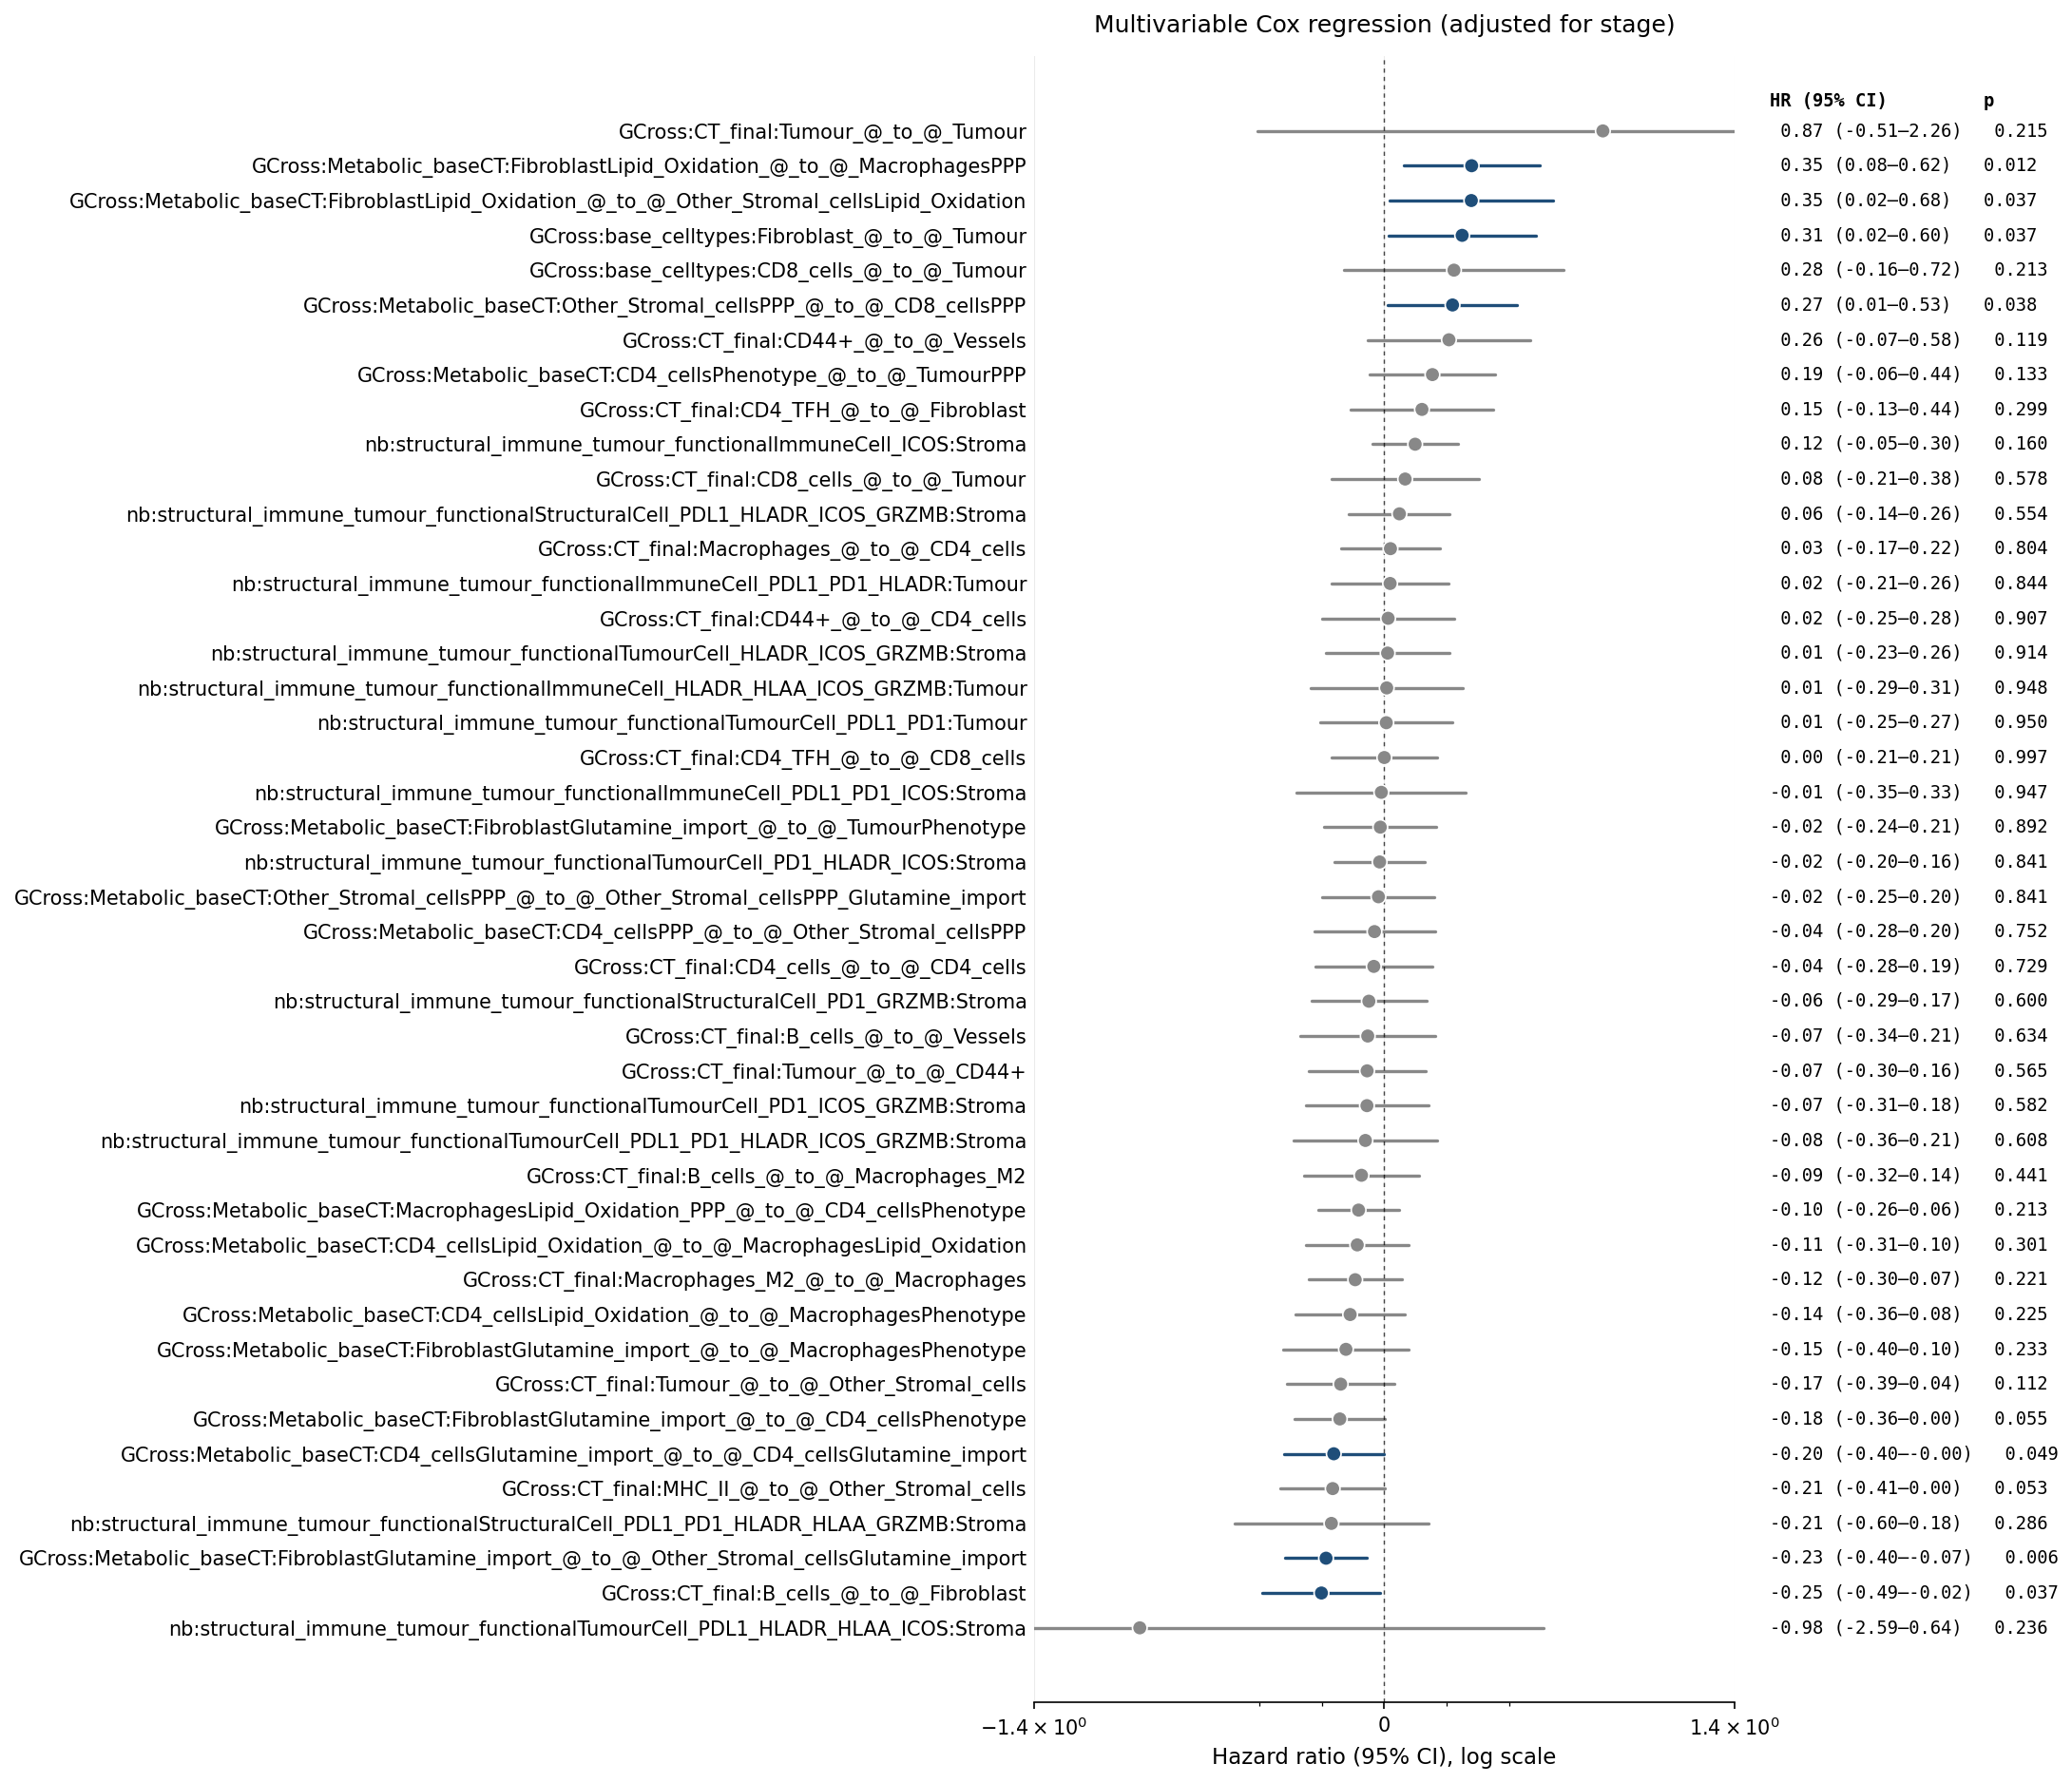

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def compute_cox_HRs(X_, Y_, features):

    results = []

    for feat in features:
        vals = X_[[feat]]
        clin = pd.concat([Y_[['Relapse_status', 'Relapse_followup', 'patientID']], stages3.to_frame('stage3'), stages3.to_frame('stage2'), sex.to_frame('sex')], axis=1).groupby(by='patientID').first()
        scaler = StandardScaler()
        imputer = SimpleImputer(strategy='median')
        vals = pd.DataFrame(imputer.fit_transform(vals), index=vals.index, columns=imputer.get_feature_names_out())
        vals = pd.DataFrame(scaler .fit_transform(vals), index=vals.index, columns=scaler .get_feature_names_out())
        vals = pd.concat([vals, Y_.loc[vals.index, ['patientID']]], axis=1).groupby(by='patientID').mean()
        vals = pd.concat([vals, clin.loc[vals.index,:]], axis=1)
        vals = vals.loc[vals['Relapse_followup'] != '#VALUE!',:]
        vals['Relapse_followup'] = vals['Relapse_followup'].astype(float)
        vals = vals.loc[:,vals.columns != 'patientID']

        print(vals)

        from lifelines import CoxPHFitter
        cph = CoxPHFitter(penalizer=1e-5)
        cph.fit(vals, duration_col='Relapse_followup', event_col='Relapse_status')
        results.append(cph.summary)

    return pd.concat(results, axis=0)

def plot_cox_forest(results_df, features=None,
                    title='Multivariable Cox regression (adjusted for stage)',
                    figsize=None, save_path=None):
    """
    Forest plot from concatenated lifelines CoxPHFitter.summary outputs.

    Parameters
    ----------
    results_df : DataFrame returned by compute_cox_HRs (rows indexed by covariate).
    features   : optional list to subset/order. If None, drops stage dummies and
                 sorts by HR.
    """
    df = results_df.copy()
    #df = df.groupby(by='patientID').mean()
    print(df)
    if features is not None:
        df = df.loc[features]
        df = df.sort_values('coef')
    else:
        df = df.drop(index=[c for c in ('stage2', 'stage3') if c in df.index],
                     errors='ignore')
        df = df[~df.index.duplicated(keep='first')]
        df = df.sort_values('coef')


    n = len(df)
    if figsize is None:
        figsize = (7.5, max(2.5, 15))

    hr   = df['exp(coef)'].apply(np.log10).values
    lo   = df['exp(coef) lower 95%'].apply(np.log10).values
    hi   = df['exp(coef) upper 95%'].apply(np.log10).values
    pval = df['p'].values
    y    = np.arange(n)

    colors = ['#B22222' if (p < 0.05 and h > 1) else
              '#1F4E79' if (p < 0.05 and h < 1) else
              '#888888' for h, p in zip(hr, pval)]

    fig, ax = plt.subplots(figsize=figsize, dpi=150)

    for i, (l, h, c) in enumerate(zip(lo, hi, colors)):
        ax.plot([l, h], [i, i], color=c, lw=1.6, solid_capstyle='round', zorder=2)
    ax.scatter(hr, y, s=55, c=colors, edgecolor='white', lw=0.8, zorder=3)

    ax.axvline(0, color='black', ls=(0, (3, 3)), lw=0.7, alpha=0.7)

    ax.set_xscale('symlog')
    xmin = min(lo) / 1.3
    xmax = max(hi) * 1.3
    ax.set_xlim(-1.4, 1.4)#xmin, xmax)

    ax.set_yticks(y)
    ax.set_yticklabels(df.index, fontsize=10)
    ax.set_xlabel('Hazard ratio (95% CI), log scale', fontsize=11)
    ax.set_title(title, fontsize=12, pad=12)

    trans = ax.get_yaxis_transform()  
    x_text = 1.05                     

    ax.text(x_text, n - 0.4, 'HR (95% CI)         p',
            transform=trans,
            fontsize=9, family='monospace', fontweight='bold',
            va='bottom', clip_on=False)

    for i, (h, l, u, p) in enumerate(zip(hr, lo, hi, pval)):
        p_str = '<0.001' if p < 0.001 else f'{p:.3f}'
        ax.text(x_text, i, f'{h:>5.2f} ({l:.2f}–{u:.2f})   {p_str}',
                transform=trans,
                fontsize=9, family='monospace',
                va='center', clip_on=False)

    for s in ('top', 'right', 'left'):
        ax.spines[s].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.grid(axis='x', alpha=0.25, lw=0.5)
    ax.set_axisbelow(True)

    fig.subplots_adjust(right=0.78)
    from matplotlib.ticker import FixedLocator
    ax.xaxis.set_minor_locator(FixedLocator([-0.5, -0.25, 0.0, 0.25, 0.5]))

    #plt.tight_layout()
    if save_path:
        fig.savefig(save_path, bbox_inches='tight', dpi=300)
    return fig, ax

stages = adata.obs.groupby(by='unique_core').first().loc[X_raw.index,:]['stage_grouped']
stages2 = stages == 'stage2'
stages3 = stages == 'stage3'
sex = adata.obs.groupby(by='unique_core').first().loc[X_raw.index,:]['Sex']
sex = sex == 'M'
    
results = compute_cox_HRs(X_surv,
                          dfPatientAnnData[['Relapse_status', 'Relapse_followup', 'patientID']],
                          top_features)
results.to_csv('cox_forest_LUAD_relapsestatus.csv')

plot_cox_forest(results, features=top_features,
                save_path='Figure6e.pdf')


#results = compute_cox_HRs(X_surv,
#                          dfPatientAnnData.loc[X_surv.index, ['Relapse_status', 'Relapse_followup']],
#                          top_features)
#results.to_csv('cox_forest_LUAD_relapsestatus.csv')
#
#plot_cox_forest(results, features=top_features,
#                save_path='cox_forest_LUAD_relapsestatus.svg')

In [155]:
Y

,Relapse_status
TMA_A_A1,0.0
TMA_A_A3,1.0
TMA_A_A4,0.0
TMA_A_A7,1.0
TMA_A_B3,1.0
...,...
TMA_B_J2,1.0
TMA_B_J3,0.0
TMA_B_J4,1.0
TMA_B_J7,0.0


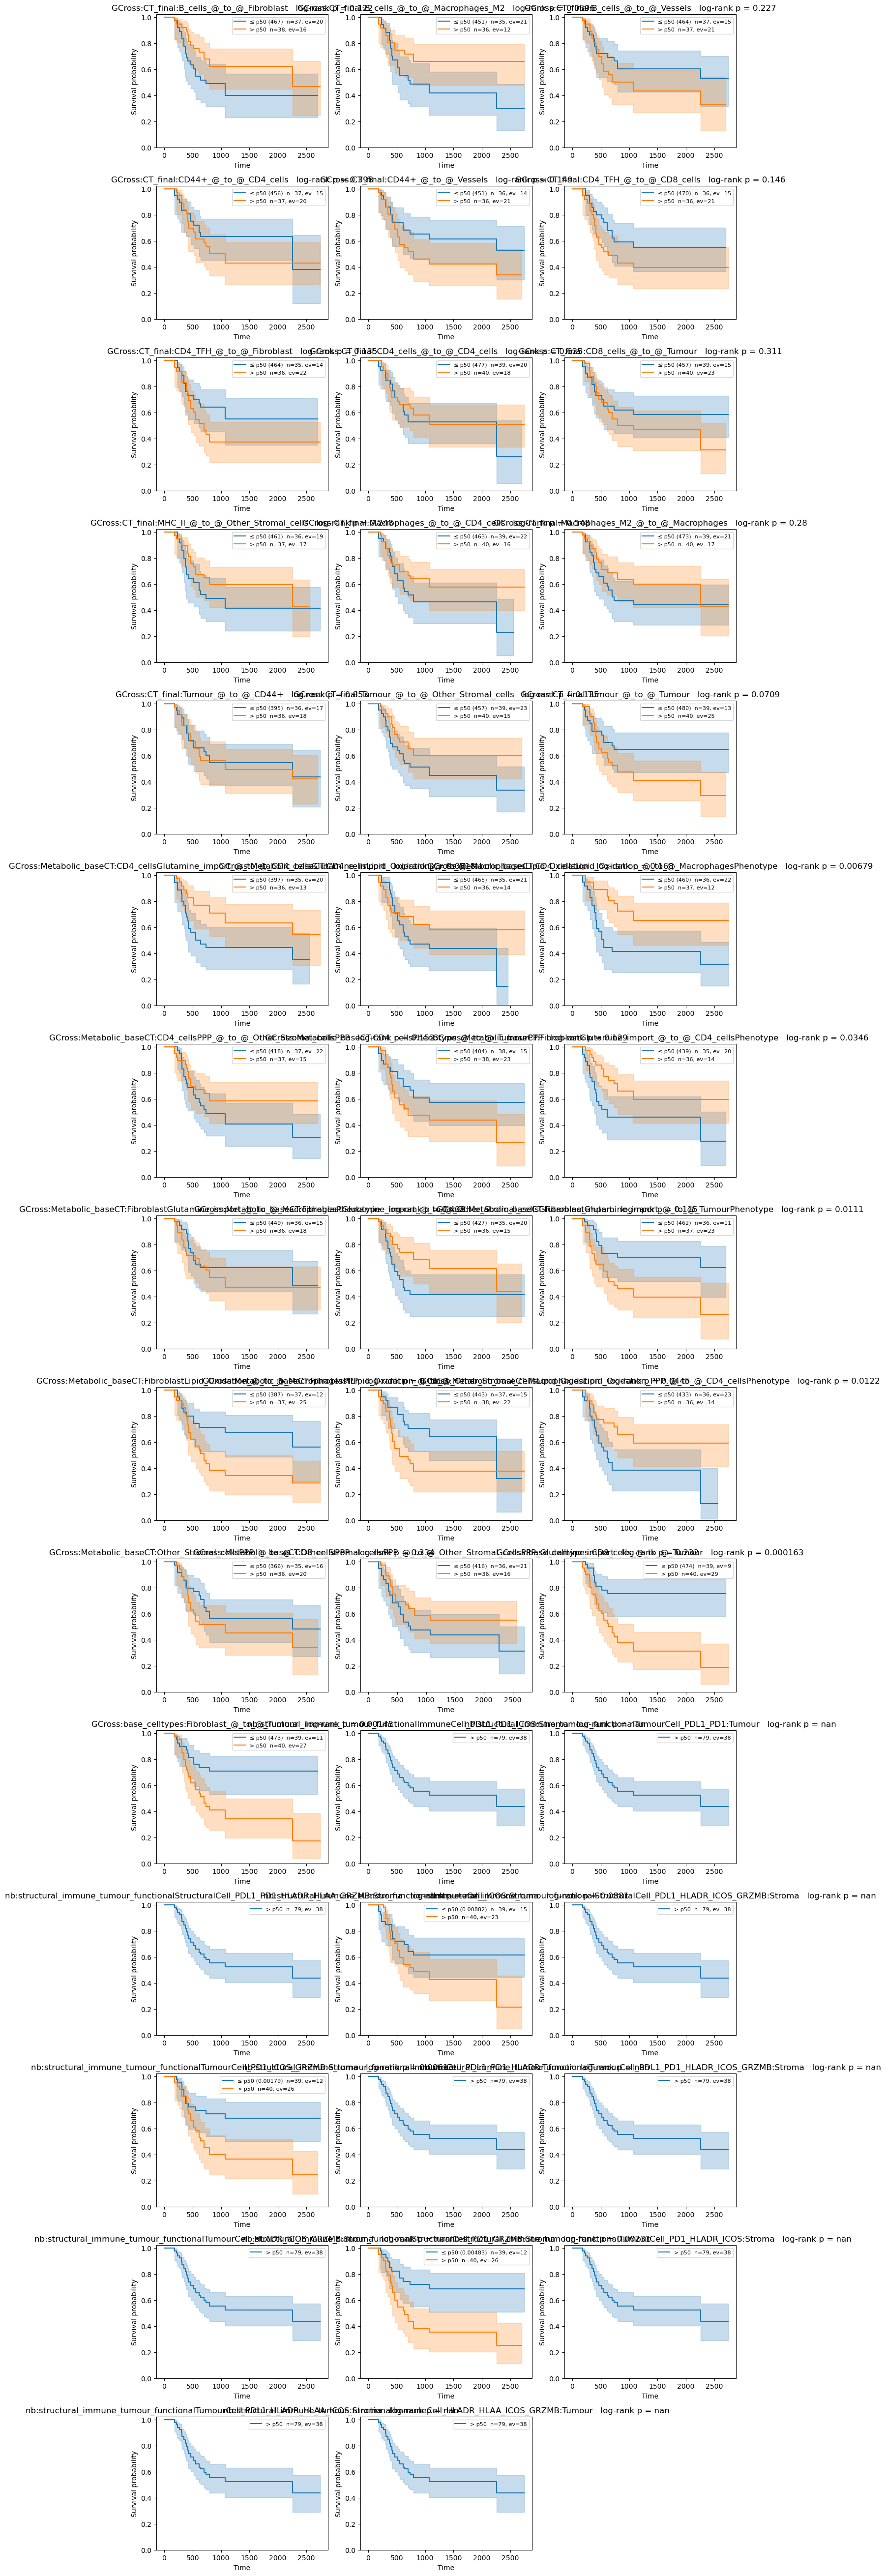

In [86]:
r, f = km_by_percentile(
    X_surv,
    Y_surv,
    top_features,
    percentiles=50
    )

In [ ]:
top_features_sig = top_features

/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:86: UserWarning: The groups parameter is ignored by SurvivalStratifiedGroupRepeatedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
/Users/aaronkilgallon/miniconda3/envs/analysis/lib/python3.13/site-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(



CoxPH: 40 valid folds  |  RSF: 40 valid folds  |  GBSA: 40 valid folds


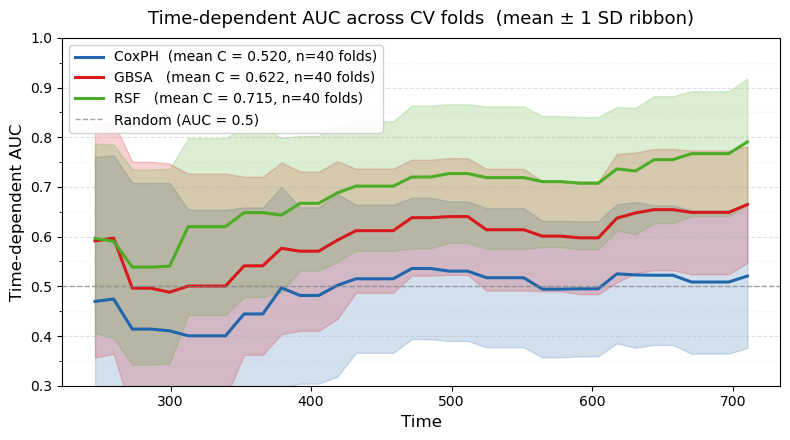

In [ ]:
from sksurv.metrics import cumulative_dynamic_auc
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from numpy.linalg import LinAlgError
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

final_splitter = SurvivalStratifiedGroupRepeatedKFold(
    n_splits=4, n_repeats=10, random_state=random_state
)


def _safe_interp(eval_times, fold_times, auc):
    auc = np.asarray(auc, dtype=float)
    mask = np.isfinite(auc)
    if mask.sum() < 2:
        return np.full_like(eval_times, np.nan, dtype=float)
    return np.interp(eval_times, fold_times[mask], auc[mask],
                     left=np.nan, right=np.nan)


def _coverage_masked_summary(fold_aucs, min_frac=0.5):
    fold_aucs = np.asarray(fold_aucs, dtype=float)
    coverage  = np.isfinite(fold_aucs).sum(axis=0)
    threshold = max(2, int(np.ceil(min_frac * len(fold_aucs))))
    mean = np.nanmean(fold_aucs, axis=0)
    sd   = np.nanstd(fold_aucs,  axis=0)
    keep = coverage >= threshold
    mean = np.where(keep, mean, np.nan)
    sd   = np.where(keep, sd,   np.nan)
    return mean, sd


def _fold_time_window(Y_tr, Y_te, eval_times, right_edge_frac=0.9):
    tr_event_t = Y_tr["time"][Y_tr["event"] == 1]
    te_event_t = Y_te["time"][Y_te["event"] == 1]
    if len(tr_event_t) == 0 or len(te_event_t) == 0:
        return np.array([], dtype=float)
    t_lo  = max(Y_tr["time"].min(), Y_te["time"].min())
    t_hi  = right_edge_frac * min(tr_event_t.max(), te_event_t.max())
    return eval_times[(eval_times > t_lo) & (eval_times < t_hi)]


t_min, t_max = np.percentile(Y_surv["time"][Y_surv["event"] == 1], [10, 90])
eval_times = np.linspace(t_min, t_max, 50)

cox_fold_aucs  = []
rsf_fold_aucs  = []
gbsa_fold_aucs = []
rsf_fold_c     = []
gbsa_fold_c    = []

for fold_i, (train_idx, test_idx) in enumerate(
        final_splitter.split(X_surv, Y_surv, groups=patient_groups_surv)):

    X_tr_raw = X_surv[top_features_sig].iloc[train_idx, :]
    X_te_raw = X_surv[top_features_sig].iloc[test_idx, :]
    Y_tr     = Y_surv[train_idx]
    Y_te     = Y_surv[test_idx]

    fold_times = _fold_time_window(Y_tr, Y_te, eval_times)

    if len(fold_times) < 5:
        print(f"Fold {fold_i}: skipped — fewer than 5 valid time points")
        continue

    imputer = SimpleImputer(strategy="median")
    scaler  = StandardScaler()
    X_tr_sc_im = scaler.fit_transform(imputer.fit_transform(X_tr_raw))
    X_te_sc_im = scaler.transform(imputer.transform(X_te_raw))

    scaler  = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr_raw)
    X_te_sc = scaler.transform(X_te_raw)

    # CoxPH
    try:
        cox_model = CoxPHSurvivalAnalysis(ties="efron", alpha=0.1)
        cox_model.fit(X_tr_sc_im, Y_tr)
        cox_risk = cox_model.predict(X_te_sc_im)

        cox_auc, _ = cumulative_dynamic_auc(Y_tr, Y_te, cox_risk, fold_times)
        cox_fold_aucs.append(_safe_interp(eval_times, fold_times, cox_auc))

    except (LinAlgError, ValueError) as e:
        print(f"Fold {fold_i}: CoxPH skipped — {type(e).__name__}: {e}")

    # RandomSurvivalForest 
    try:
        imputer_rsf = StandardScaler()
        X_tr_rsf    = imputer_rsf.fit_transform(X_tr_raw)
        X_te_rsf    = imputer_rsf.transform(X_te_raw)

        rsf_model = RandomSurvivalForest(
            **{key: value for key, value in best_params.items()}
        )

        rsf_model.fit(X_tr_rsf, Y_tr)
        rsf_risk = rsf_model.predict(X_te_rsf)
        rsf_fold_c.append(rsf_model.score(X_te_rsf, Y_te))

        rsf_auc, _ = cumulative_dynamic_auc(Y_tr, Y_te, rsf_risk, fold_times)
        rsf_fold_aucs.append(_safe_interp(eval_times, fold_times, rsf_auc))

    except (ValueError,) as e:
        print(f"Fold {fold_i}: RSF skipped — {type(e).__name__}: {e}")

    # GradientBoostingSurvivalAnalysis 
    try:
        gbsa_model = sksurv.ensemble.ComponentwiseGradientBoostingSurvivalAnalysis(
            **{'learning_rate': 1.0, 'n_estimators': 500, 'subsample': 1.0},
            random_state=random_state,
        )
        gbsa_model.fit(X_tr_sc_im, Y_tr)
        gbsa_risk = gbsa_model.predict(X_te_sc_im)
        gbsa_fold_c.append(gbsa_model.score(X_te_sc_im, Y_te))

        gbsa_auc, _ = cumulative_dynamic_auc(Y_tr, Y_te, gbsa_risk, fold_times)
        gbsa_fold_aucs.append(_safe_interp(eval_times, fold_times, gbsa_auc))

    except (ValueError,) as e:
        print(f"Fold {fold_i}: GBSA skipped — {type(e).__name__}: {e}")

print(f"\nCoxPH: {len(cox_fold_aucs)} valid folds  |  "
      f"RSF: {len(rsf_fold_aucs)} valid folds  |  "
      f"GBSA: {len(gbsa_fold_aucs)} valid folds")

if not cox_fold_aucs and not rsf_fold_aucs and not gbsa_fold_aucs:
    raise RuntimeError("No valid folds — check your data / splitter settings.")

cox_fold_aucs  = np.array(cox_fold_aucs)
rsf_fold_aucs  = np.array(rsf_fold_aucs)
gbsa_fold_aucs = np.array(gbsa_fold_aucs)

cox_mean,  cox_sd  = _coverage_masked_summary(cox_fold_aucs)
rsf_mean,  rsf_sd  = _coverage_masked_summary(rsf_fold_aucs)
gbsa_mean, gbsa_sd = _coverage_masked_summary(gbsa_fold_aucs)

fig, ax = plt.subplots(figsize=(8, 4.5))

COX_COLOR  = "#2166ac"
RSF_COLOR  = "#4dac26"
GBSA_COLOR = "#d7191c"

#for fold_auc in cox_fold_aucs:
#    ax.plot(eval_times, fold_auc, color=COX_COLOR, alpha=0.15, lw=0.8)
#for fold_auc in gbsa_fold_aucs:
#    ax.plot(eval_times, fold_auc, color=GBSA_COLOR, alpha=0.15, lw=0.8)

ax.fill_between(eval_times, cox_mean - cox_sd, cox_mean + cox_sd,
                color=COX_COLOR, alpha=0.20)
ax.fill_between(eval_times, gbsa_mean - gbsa_sd, gbsa_mean + gbsa_sd,
                color=GBSA_COLOR, alpha=0.20)
ax.fill_between(eval_times, rsf_mean - rsf_sd, rsf_mean + rsf_sd,
                color=RSF_COLOR, alpha=0.20)

ax.plot(eval_times, cox_mean, color=COX_COLOR, lw=2.2,
        label=f"CoxPH  (mean C = {np.nanmean(standard_fold_c):.3f},"
              f" n={len(cox_fold_aucs)} folds)")
ax.plot(eval_times, gbsa_mean, color=GBSA_COLOR, lw=2.2,
        label=f"GBSA   (mean C = {np.nanmean(gbsa_fold_c):.3f},"
              f" n={len(gbsa_fold_aucs)} folds)")
ax.plot(eval_times, rsf_mean, color=RSF_COLOR, lw=2.2,
        label=f"RSF   (mean C = {np.nanmean(rsf_fold_c):.3f},"
              f" n={len(rsf_fold_aucs)} folds)")

ax.axhline(0.5, color="grey", lw=1, ls="--", alpha=0.7, label="Random (AUC = 0.5)")

ax.set_xlabel("Time", fontsize=12)
ax.set_ylabel("Time-dependent AUC", fontsize=12)
ax.set_title("Time-dependent AUC across CV folds  (mean ± 1 SD ribbon)",
             fontsize=13, pad=10)
ax.set_ylim(0.3, 1.0)
ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.05))
ax.grid(axis="y", which="major", ls="--", alpha=0.4)
ax.grid(axis="y", which="minor", ls=":",  alpha=0.2)
ax.legend(framealpha=0.9, fontsize=10)

plt.tight_layout()
plt.savefig("Figure6g.svg", dpi=200, bbox_inches="tight")
plt.show()


In [156]:
cox_model.coef_

array([ 0.57307146, -0.38372583, -0.0017406 , -0.47993965,  0.07107267,
        0.05306917, -0.70322427])

In [ ]:
# Directed chord diagram 
import matplotlib.colors as mcolors

def draw_chord_diagram(
    edges,
    preferred_order=None,
    node_colors=None,
    figsize=(9, 9),
    R=0.82,
    sub_arc_w=0.06,
    arc_w=0.04,
    gap_deg=5.0,
    sub_gap_deg=1.2,
    label_pad=0.22,
    subtype_label_pad=0.08,
    chord_alpha=0.52,
    self_loop_bump=0.30,
    title='',
    fontsize=10,
    subtype_fontsize=7,
):
    from collections import defaultdict

    parsed = []
    for e in edges:
        ct1, ct2, w = e[0], e[1], float(e[2])
        ft1 = e[4] if len(e) > 4 else None
        ft2 = e[5] if len(e) > 5 else None
        parsed.append(((ct1, ft1), (ct2, ft2), w))

    ct_fts = defaultdict(set)
    for (ct1, ft1), (ct2, ft2), w in parsed:
        ct_fts[ct1].add(ft1)
        ct_fts[ct2].add(ft2)

    # None (base level, no subtype) sorted first, then subtypes alphabetically
    ct_leaves = {
        ct: ([None] if None in fts else []) + sorted(f for f in fts if f is not None)
        for ct, fts in ct_fts.items()
    }

    all_cts = set(ct_fts)
    if preferred_order is None:
        ct_order = sorted(all_cts)
    else:
        ct_order = [c for c in preferred_order if c in all_cts]
        ct_order += sorted(c for c in all_cts if c not in ct_order)
    ct_idx = {c: i for i, c in enumerate(ct_order)}

    if node_colors is None:
        cmap = plt.cm.tab10
        node_colors = {ct: cmap(i % 10) for i, ct in enumerate(ct_order)}

    leaf_weight = defaultdict(float)
    for src, tgt, w in parsed:
        leaf_weight[src] += w
        leaf_weight[tgt] += w

    ct_weight = {
        ct: sum(leaf_weight[(ct, ft)] for ft in fts)
        for ct, fts in ct_leaves.items()
    }
    total_w = sum(ct_weight.values())

    gap     = np.radians(gap_deg)
    sub_gap = np.radians(sub_gap_deg)
    n_cts   = len(ct_order)
    avail   = 2 * np.pi - gap * n_cts

    ct_total_span = {
        ct: avail * (ct_weight[ct] / total_w) if total_w > 0 else avail / n_cts
        for ct in ct_order
    }

    leaf_start, leaf_end     = {}, {}
    ct_arc_start, ct_arc_end = {}, {}

    cur = np.pi / 2
    for ct in ct_order:
        ct_arc_start[ct] = cur
        fts   = ct_leaves[ct]
        n_l   = len(fts)
        ct_lw = ct_weight[ct]

        leaf_avail = ct_total_span[ct] - sub_gap * (n_l - 1)

        cur_l = cur
        for j, ft in enumerate(fts):
            lw   = leaf_weight[(ct, ft)]
            span = leaf_avail * (lw / ct_lw) if ct_lw > 0 else leaf_avail / n_l
            leaf_start[(ct, ft)] = cur_l
            leaf_end[(ct, ft)]   = cur_l - span
            cur_l -= span
            if j < n_l - 1:
                cur_l -= sub_gap

        ct_arc_end[ct] = cur_l
        cur = cur_l - gap

    src_arc, tgt_arc = {}, {}

    for ct in ct_order:
        for ft in ct_leaves[ct]:
            leaf  = (ct, ft)
            out_e = [(i, s, t, w) for i, (s, t, w) in enumerate(parsed) if s == leaf]
            in_e  = [(i, s, t, w) for i, (s, t, w) in enumerate(parsed) if t == leaf]

            la_s   = leaf_start[leaf]
            la_e   = leaf_end[leaf]
            span   = la_s - la_e
            o_tot  = sum(w for *_, w in out_e)
            i_tot  = sum(w for *_, w in in_e)
            nd_tot = o_tot + i_tot

            out_span = span * (o_tot / nd_tot) if nd_tot > 0 else span / 2
            in_span  = span - out_span

            # Outgoing sorted by target CT
            cur_a = la_s
            for i, s, t, w in sorted(out_e, key=lambda x: ct_idx.get(x[2][0], 0)):
                frac = w / o_tot if o_tot > 0 else 1.0 / max(len(out_e), 1)
                src_arc[i] = (cur_a, cur_a - out_span * frac)
                cur_a -= out_span * frac

            # Incoming sorted by source CT
            cur_a = la_e
            for i, s, t, w in sorted(in_e, key=lambda x: ct_idx.get(x[1][0], 0)):
                frac = w / i_tot if i_tot > 0 else 1.0 / max(len(in_e), 1)
                e_span = in_span * frac
                tgt_arc[i] = (cur_a + e_span, cur_a)
                cur_a += e_span

    total_arc_r = R + sub_arc_w + arc_w
    pad = total_arc_r + label_pad + 0.4
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_xlim(-pad, pad)
    ax.set_ylim(-pad, pad)

    # Inner subtype arcs — chord attachment layer
    for ct in ct_order:
        base_rgb = np.array(mcolors.to_rgb(node_colors.get(ct, '#888')))
        fts = ct_leaves[ct]
        n_l = len(fts)
        for j, ft in enumerate(fts):
            # Single subtype: full base color; multiple: lighten progressively
            t = j / (n_l - 1) if n_l > 1 else 0.0
            face_color = tuple(base_rgb + (1.0 - base_rgb) * (0.0 + 0.55 * t))
            ax.add_patch(Wedge(
                center=(0, 0), r=R + sub_arc_w,
                theta1=np.degrees(leaf_end[(ct, ft)]),
                theta2=np.degrees(leaf_start[(ct, ft)]),
                width=sub_arc_w, color=face_color, zorder=4, linewidth=0,
            ))

    # Outer CT arcs
    for ct in ct_order:
        ax.add_patch(Wedge(
            center=(0, 0), r=total_arc_r,
            theta1=np.degrees(ct_arc_end[ct]),
            theta2=np.degrees(ct_arc_start[ct]),
            width=arc_w, color=node_colors.get(ct, '#888'), zorder=5, linewidth=0,
        ))

    # Labels
    for ct in ct_order:
        color = node_colors.get(ct, '#888')
        fts   = ct_leaves[ct]
        n_l   = len(fts)

        # CT label
        mid_a = (ct_arc_start[ct] + ct_arc_end[ct]) / 2
        lx = (total_arc_r + label_pad) * np.cos(mid_a)
        ly = (total_arc_r + label_pad) * np.sin(mid_a)
        ha  = 'left' if np.cos(mid_a) >= 0 else 'right'
        rot = np.degrees(mid_a)
        if np.cos(mid_a) < 0:
            rot += 180
        ax.text(lx, ly, display_label(ct), ha=ha, va='center',
                fontsize=fontsize, rotation=rot, rotation_mode='anchor',
                fontweight='bold', color=color)

        # Subtype labels 
        if n_l > 1:
            for ft in fts:
                if ft is None:
                    continue
                mid_a = (leaf_start[(ct, ft)] + leaf_end[(ct, ft)]) / 2
                lx = (total_arc_r + subtype_label_pad) * np.cos(mid_a)
                ly = (total_arc_r + subtype_label_pad) * np.sin(mid_a)
                ha  = 'left' if np.cos(mid_a) >= 0 else 'right'
                rot = np.degrees(mid_a)
                if np.cos(mid_a) < 0:
                    rot += 180
                ax.text(lx, ly, ft, ha=ha, va='center',
                        fontsize=subtype_fontsize, rotation=rot, rotation_mode='anchor',
                        style='italic', color=color)

    # Chords
    max_w = max((w for *_, w in parsed), default=1.0)
    ctrl  = np.zeros(2)

    for i, (src, tgt, w) in enumerate(parsed):
        ct1, ft1 = src
        ct2, ft2 = tgt
        color = node_colors.get(ct1, '#888')

        if src == tgt:
            # Self-loop: outward bezier bump beyond both arc bands
            sa0, sa1 = src_arc.get(i, (leaf_start[src], leaf_end[src]))
            mid_a = (sa0 + sa1) / 2
            span  = abs(sa0 - sa1)
            p0 = pt(R, sa0)
            p3 = pt(R, sa1)
            bump_r = total_arc_r + self_loop_bump * (0.4 + 0.6 * w / max_w)
            p1 = pt(bump_r, mid_a + span * 0.35)
            p2 = pt(bump_r, mid_a - span * 0.35)
            lw = 1.8 + 3.5 * (w / max_w)
            ax.add_patch(mpatches.PathPatch(
                Path([p0, p1, p2, p3],
                     [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]),
                facecolor='none', edgecolor=color, lw=lw,
                alpha=min(chord_alpha + 0.18, 0.9), zorder=3,
            ))
            tan_dir = np.array([np.sin(sa1), -np.cos(sa1)])
            ax.annotate('', xy=p3, xytext=p3 + tan_dir * 0.12,
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.5,
                                        mutation_scale=12), zorder=6)

        else:
            sa0, sa1 = src_arc.get(i, (leaf_start[src], leaf_end[src]))
            ta0, ta1 = tgt_arc.get(i, (leaf_start[tgt], leaf_end[tgt]))

            p_s0, p_s1 = pt(R, sa0), pt(R, sa1)
            p_t0, p_t1 = pt(R, ta0), pt(R, ta1)

            verts = [p_s0, ctrl, ctrl, p_t0, p_t1, ctrl, ctrl, p_s1, [0., 0.]]
            codes = [Path.MOVETO,
                     Path.CURVE4, Path.CURVE4, Path.CURVE4,
                     Path.LINETO,
                     Path.CURVE4, Path.CURVE4, Path.CURVE4,
                     Path.CLOSEPOLY]
            ax.add_patch(mpatches.PathPatch(
                Path(verts, codes),
                facecolor=color, edgecolor='none',
                alpha=chord_alpha, zorder=2,
            ))

            tgt_mid_a = (ta0 + ta1) / 2
            tip  = pt(R, tgt_mid_a)
            tail = pt(R * 0.84, tgt_mid_a)
            ax.annotate('', xy=tip, xytext=tail,
                        arrowprops=dict(arrowstyle='->', color=color, lw=1.6,
                                        mutation_scale=14), zorder=6)

    if title:
        ax.set_title(title, fontsize=12, fontweight='bold', pad=20)

    return fig, ax

In [ ]:
CT_RENAME = {
    'CD44+': 'Tumour',
    'MHC_II': 'Tumour',
    'Proliferating': 'Tumour',
    'B_cells': 'Bcells',
    'CD4_TFH': 'CD4TFH',
    'Macrophages_M2': 'MacrophagesM2',
    'CD4_cellsGlutamine_import': 'CD4cells_Glutamineimport',
    'CD4_cellsLipid_Oxidation': 'CD4cells_LipidOxidation',
    'MacrophagesLipid_Oxidation': 'Macrophages_LipidOxidation',
    'MacrophagesPhenotype': 'Macrophages_lowmeta',
    'CD4_cellsPPP': 'CD4cells_PPP',
    'Other_Stromal_cellsPPP': 'OtherStromalcells_PPP',
    'CD4_cellsPhenotype': 'CD4cells_Phenotype',
    'TumourPPP': 'Tumour_PPP',
    'FibroblastGlutamine_import': 'Fibroblast_Glutamineimport',
    'CD4_cellsPhenotype': 'CD4cells_Phenotype',
    'Other_Stromal_cellsGlutamine_import': 'OtherStromalcells_Glutamineimport',
    'TumourPhenotype': 'Tumour_lowmeta',
    'FibroblastLipid_Oxidation': 'Fibroblast_LipidOxidation',
    'MacrophagesPPP': 'Macrophages_PPP',
    'Other_Stromal_cellsLipid_Oxidation': 'OtherStromalcells_LipidOxidation',
    'MacrophagesLipid_Oxidation_PPP': 'Macrophages_LipidOxidationPPP',
    'CD8_cellsPPP': 'CD8cells_PPP',
    'Other_Stromal_cellsPPP': 'OtherStromalcells_PPP',
    'Other_Stromal_cellsPPP_Glutamine_import': 'OtherStromalcells_PPPGlutamineimport',
    "CD4_cells": 'CD4cells',
    "CD8_cells": 'CD8cells'
}

NODE_COLORS = {
    'Tumour':      '#C0392B',   # red
    'Bcells':     '#2980B9',   # blue
    'CD4cells':   '#27AE60',   # green
    'CD4TFH':     '#1ABC9C',   # teal
    'CD8cells':   '#8E44AD',   # purple
    'Macrophages': '#E67E22',   # orange
    'MacrophagesM2': '#E67E22',   # orange
    'Vessels':     '#7F8C8D',   # grey
}

BASE_CTS = [
    'Tumour', 'Bcells', 'CD4cells', 'CD4TFH', 'CD8cells', 'OtherStromalcells'
    'Macrophages', 'MacrophagesM2', 'Vessels',
]

In [ ]:
def parse_feature(feat):
    if '_@_to_@_' not in feat:
        return None, None
    parts = feat.split(':', 2)
    body = parts[2] if len(parts) == 3 else feat
    
    if ('_@_to_@_' not in body):
        print(body)
        return None, None
    ct1, ct2 = body.split('_@_to_@_', 1)
    if '_' in ct1:
        ct1, ft1 = ct1.split('_')[0], ct1.split('_')[1].strip()
    else:
        ct1, ft1 = ct1.split('_')[0], None

    if '_' in ct2:
        ct2, ft2 = ct2.split('_')[0], ct2.split('_')[1].strip()
    else:
        ct2, ft2 = ct2.split('_')[0], None

    if ct1 not in BASE_CTS:
        print(ct1)
    if ct2 not in BASE_CTS:
        print(ct2)
 
    return ct1.strip(), ft1, ct2.strip(), ft2

def pt(r, a):
    """Point on circle of radius r at angle a (radians)."""
    return np.array([r * np.cos(a), r * np.sin(a)])

def display_label(ct):
    return ct.replace('_', ' ')

In [119]:
results.loc[~results.index.isin(['stage2', 'stage3', 'sex']),:]

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
GCross:CT_final:B_cells_@_to_@_Fibroblast,-0.288789,0.749170,0.125606,-0.534973,-0.042606,0.585685,0.958289,0.0,-2.299165,0.021496,5.539818
GCross:CT_final:B_cells_@_to_@_Macrophages_M2,0.075574,1.078503,0.111542,-0.143044,0.294192,0.866716,1.342041,0.0,0.677535,0.498066,1.005590
GCross:CT_final:B_cells_@_to_@_Vessels,-0.124412,0.883016,0.143937,-0.406523,0.157699,0.665961,1.170814,0.0,-0.864352,0.387394,1.368125
GCross:CT_final:CD44+_@_to_@_CD4_cells,-0.011278,0.988785,0.121868,-0.250136,0.227580,0.778695,1.255558,0.0,-0.092542,0.926267,0.110500
GCross:CT_final:CD44+_@_to_@_Vessels,0.076024,1.078988,0.125981,-0.170894,0.322942,0.842911,1.381185,0.0,0.603455,0.546206,0.872482
GCross:CT_final:CD4_TFH_@_to_@_CD8_cells,-0.170984,0.842835,0.114242,-0.394894,0.052926,0.673751,1.054351,0.0,-1.496686,0.134475,2.894590
GCross:CT_final:CD4_TFH_@_to_@_Fibroblast,0.036624,1.037303,0.127632,-0.213530,0.286778,0.807728,1.332128,0.0,0.286950,0.774151,0.369313
GCross:CT_final:CD4_cells_@_to_@_CD4_cells,-0.061552,0.940304,0.126497,-0.309481,0.186378,0.733828,1.204877,0.0,-0.486586,0.626552,0.674494
GCross:CT_final:CD8_cells_@_to_@_Tumour,-0.072293,0.930258,0.126719,-0.320658,0.176072,0.725671,1.192523,0.0,-0.570501,0.568338,0.815179


In [ ]:
raw_edges = []  
skipped   = []

for feat, row in results.iterrows():
    if 'nb:' in feat or 'stage' in feat or 'sex' in feat:
        continue
    print(feat)
    for a, b in CT_RENAME.items():
        feat = feat.replace(a, b) 
    ct1, ft1, ct2, ft2,  = parse_feature(feat)
    print(ct1, ft1, ct2, ft2)
    if ct1 is None:
        skipped.append(feat)
        continue
    #ct1 = CT_RENAME.get(ct1, ct1)
    #ct2 = CT_RENAME.get(ct2, ct2)
    imp = float(abs(row['coef']))
    raw_edges.append((ct1, ct2, imp, feat, ft1, ft2))

print(f'Parsed {len(raw_edges)} edges  |  skipped {len(skipped)} non-directional features\n')
for ct1, ct2, imp, feat, ft1, ft2 in sorted(raw_edges, key=lambda x: -x[2]):
    tag = '  [self]' if ct1 == ct2 else ''
    print(f'  {ct1:>15s} -> {ct2:<15s}  imp={imp:.4f}{tag}')
    print(f'    original: {feat}')

GCross:CT_final:B_cells_@_to_@_Fibroblast
Fibroblast
Bcells None Fibroblast None
GCross:CT_final:B_cells_@_to_@_Macrophages_M2
Bcells None MacrophagesM2 None
GCross:CT_final:B_cells_@_to_@_Vessels
Bcells None Vessels None
GCross:CT_final:CD44+_@_to_@_CD4_cells
Tumour None CD4cells None
GCross:CT_final:CD44+_@_to_@_Vessels
Tumour None Vessels None
GCross:CT_final:CD4_TFH_@_to_@_CD8_cells
CD4TFH None CD8cells None
GCross:CT_final:CD4_TFH_@_to_@_Fibroblast
Fibroblast
CD4TFH None Fibroblast None
GCross:CT_final:CD4_cells_@_to_@_CD4_cells
CD4cells None CD4cells None
GCross:CT_final:CD8_cells_@_to_@_Tumour
CD8cells None Tumour None
GCross:CT_final:MHC_II_@_to_@_Other_Stromal_cells
Other
Tumour None Other Stromal
GCross:CT_final:Macrophages_@_to_@_CD4_cells
Macrophages
Macrophages None CD4cells None
GCross:CT_final:Macrophages_M2_@_to_@_Macrophages
Macrophages
MacrophagesM2 None Macrophages None
GCross:CT_final:Tumour_@_to_@_CD44+
Tumour None Tumour None
GCross:CT_final:Tumour_@_to_@_Other_St

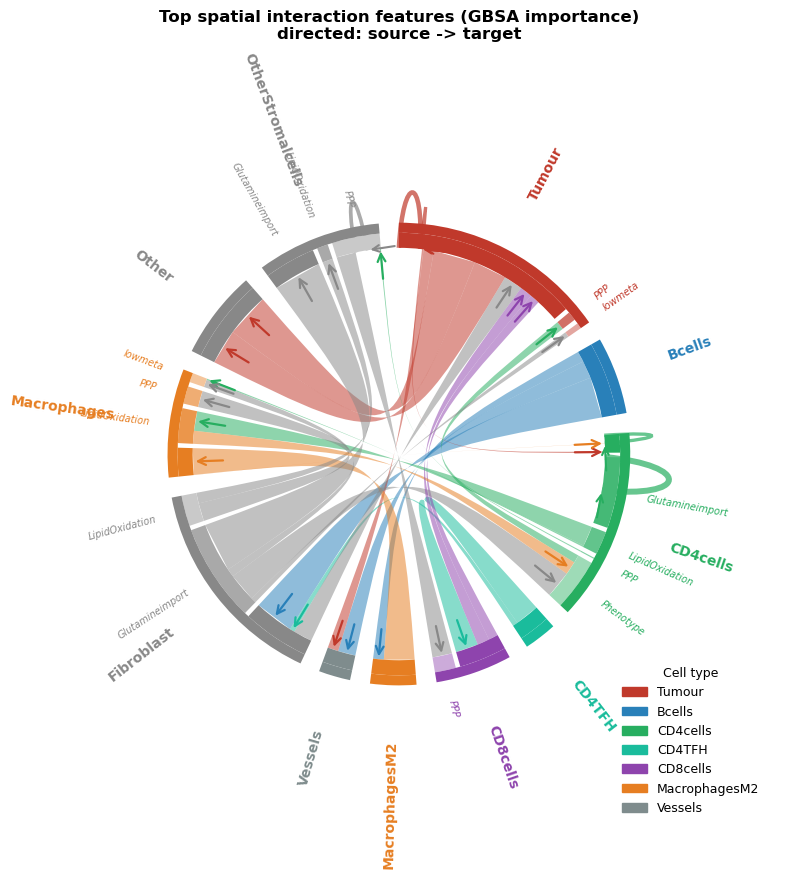

Saved: chord_diagram_top_features.pdf / .png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
from matplotlib.patches import Wedge
from collections import defaultdict
import pandas as pd

fig, ax = draw_chord_diagram(
    edges           = raw_edges,
    preferred_order = BASE_CTS,
    node_colors     = NODE_COLORS,
    figsize         = (9, 9),
    title           = 'Top spatial interaction features (GBSA importance)\ndirected: source -> target',
)

active_nodes = {s for s, t, *_ in raw_edges} | {t for s, t, *_ in raw_edges}
handles = [
    mpatches.Patch(color=NODE_COLORS.get(nd, '#888'), label=display_label(nd))
    for nd in BASE_CTS
    if nd in active_nodes
]
ax.legend(handles=handles, loc='lower right', bbox_to_anchor=(0.98, 0.02),
          frameon=False, fontsize=9, title='Cell type', title_fontsize=9)

plt.tight_layout()
plt.savefig('Figure6f.pdf', bbox_inches='tight')
plt.savefig('Figure6f.png', bbox_inches='tight', dpi=150)
plt.show()